# fermion fable: the quantized complex 16-spinor as a fluid

This notebook turns the quantized fermion fable into a fluid and checks every step with numbers.
It shows why the fermion fable is a **complex 16-spinor** (the invariant bilinear forms of
Spin(4,4) and what anticommuting variables do to them), what canonical quantization in 4+4
dimensions gives (the Krein form, the fundamental symmetry `J`, eight particle and eight
antiparticle states per momentum), and then the **Kohn–Sham Fermi sea**: its closed forms and their
numerically stable forms, verified against adaptive quadrature over `x = kF/|m|` from `1e−8` to
`1e6` and against the Rust solver `fable_fermion`; the equation of state `w_KS(x)` from 1/3 to 0;
the thermodynamic identities; the non-relativistic limit, which is Part VI's classical fable, and
the one thing that does not survive quantization, the classical crossing of the phantom divide;
the gap equation, its uniqueness criterion and a case with three roots; the minimax nature of the
no-sea functional and the convex Walecka functional; the cooling of the gas on the pre-universe;
and the Dirac-sea energy that a mass-varying fable carries.  Every number quoted is computed
below; the prose states only what the assertions of the code cells check.

## 1. How to open a notebook like this one, from a terminal

**What you need.** A Rust toolchain (`cargo`, from https://rustup.rs), Python 3 (3.10 or newer),
`git`, and an internet connection for the one-time setup, which makes a sparse clone of the
platform rustSolveIt engine (the vendored pure-Rust SUNDIALS 7.8.0 that both solvers of this
project are built on: `rustSolveIt_Win11_SUNDIALS_7_8_0` on Windows 11,
`rustSolveIt_macos-silicon_SUNDIALS_7_8_0` on Apple-silicon macOS,
`rustSolveIt_linux_SUNDIALS_7_8_0` on Linux).  Nothing else is downloaded.

**The three commands.**  From the directory that contains `fable-cosmology/`:

1. Run the setup once.  It creates the virtual environment `.venv`, installs numpy, scipy,
   matplotlib and jupyter into it, clones the engine sparsely into `rust/vendor/rustSolveIt`,
   builds the two solvers `rust/fable_cosmo` and `rust/fable_fermion` with `cargo build --release`
   and prints their versions:

       bash fable-cosmology/setup.sh
       powershell -ExecutionPolicy Bypass -File fable-cosmology\setup.ps1      (Windows PowerShell)

2. Change into the project:

       cd fable-cosmology

3. Start JupyterLab on the notebooks folder:

       .venv/bin/jupyter lab notebooks/
       .venv\Scripts\jupyter.exe lab notebooks\        (Windows)

A browser tab opens.  Click this notebook in the file list on the left.  When Jupyter asks for a
kernel, pick **`Python 3 (ipykernel)`** -- it is the kernel of the `.venv` you just made, so
numpy, scipy and matplotlib are all there.  Run a cell with **`Shift+Enter`**: the cursor moves
to the next cell, and the outputs (text, tables, figures) appear under the cell.  Run the cells
in order from the top; `Run > Run All Cells` does that in one go.  Every cell finishes in well
under a minute on a laptop.

If a cell says the solver binary is missing, the setup was not run (or not finished): run step 1
again and watch for its last line, `== setup complete`.  To rebuild this notebook's solver alone,
run `cargo build --release` inside `rust/fable_fermion`; its own tests run with
`cargo test --release` in the same folder.

## 2. The words used in this notebook

- **field** -- a quantity defined at every point of space-time.  `fable` is a spinor field Ψ with
  sixteen components per point that rotate into each other under Spin(4,4), the symmetry group of
  the 8-dimensional pre-universe.  In Part VI of the Mathematica notebook (the classical fable) the
  sixteen components are real commuting numbers; here they are quantized.
- **complex 16-spinor** -- the fermion fable: sixteen *complex* anticommuting components.  It is
  the minimal field that uses the author's spinor metric σ16, propagates, admits a potential
  V(s) of s = Ψbar Ψ, and reduces to Part VI's field as its real commuting shadow.
- **Grassmann numbers** -- anticommuting variables, θ1 θ2 = −θ2 θ1, so θ1² = 0; the classical
  variables of a fermion field.  A bilinear θᵀ M θ keeps only the antisymmetric part of M.
- **Dirac conjugate** -- Ψbar = Ψ^‡ σ16, with Ψ^‡ the complex-conjugate transpose and
  σ16 = T16[0] T16[1] T16[2] T16[3] the author's spinor metric; s = Ψbar Ψ is the scalar density.
- **anticommutator** -- {A, B} = AB + BA.  A fermion field is quantized by prescribing
  anticommutators, {Ψ_a(x), Ψ^‡_b(y)}, instead of commutators.
- **Krein space** -- a vector space with an *indefinite* inner product.  Here the form u^‡ G u
  with G = −i σ16 γ⁴ has eight positive and eight negative directions, so the naive quantization
  has states of negative norm.
- **fundamental symmetry J** -- an operator with J² = 1 that turns an indefinite form into a
  positive one.  Here J = −i T16[0] T16[1] T16[2] T16[3] T16[4]; the Hilbert adjoint is
  Ψ^† := Ψ^‡ J.
- **Fock space** -- the Hilbert space of states with any number of particles, built by applying
  creation operators to the vacuum.
- **Dirac sea** -- the vacuum in which every negative-frequency mode is filled.  Its holes are the
  antiparticles, and energies are measured from it (normal ordering).
- **Kohn–Sham** -- the density-functional method that replaces an interacting system by
  non-interacting quasiparticles moving in a self-consistent mean field.  Here the mean field is
  the mass m = W′(σ), with W(σ) := V(Hσ) and σ = ⟨χbar χ⟩, χ = Ψ/√H.
- **gap equation** -- the self-consistency condition m = W′(σ_KS(m, kF)/v): the mass of the
  quasiparticles fixes their scalar density, and the scalar density fixes the mass.
- **Fermi momentum kF** -- the radius of the filled momentum ball; with g = 8 states per
  momentum the number density is n = g kF³/(6π²).
- **degenerate gas** -- fermions at zero temperature, filling every state with |k| < kF.  Its
  pressure comes from the Pauli principle, not from heat.
- **ΔN_eff** -- extra radiation, counted in units of the energy density of one massless neutrino
  species: ΔN_eff = ρ_f / ρ_ν(1 species).  Nucleosynthesis (BBN) and the cosmic microwave
  background allow about 0.3.
- **stabilizing stress** -- the zero-energy pressure P_stab = −F/2 on the hidden directions that
  holds the hidden sheet fixed in the model `fable4d`.  It is a Lagrange multiplier, not a stress
  derived from any field.
- **null energy condition** -- ρ + P ≥ 0 for every direction and every component.  A component
  with zero energy density and negative pressure violates it.
- **Bianchi-I** -- a homogeneous but anisotropic metric with one scale factor per direction:
  ds² = C² dz² + A² dx_obs² − dt² − B² dx_hid².
- **hidden sheet** -- the directions x5, x6, x7 (timelike in the 4+4 signature, scale factor B),
  together with the hidden spacelike coordinate x0 (scale factor C, proper coordinate z).
- **Newton constant variation** -- the observed Newton constant is G_4 = G_8 / V_hid, with V_hid
  proportional to B³ C.  If the hidden sheet moves, G_4 changes; lunar laser ranging allows
  |d ln G/dt| < 1e−13 per year today, and nucleosynthesis allows |ΔG/G| of about 0.1 since then.
- **Lagrangian** -- the function L of a field and its derivatives whose integral (the action) is
  stationary on the physical solutions; in curved space-time it carries the factor Sqrt[|det g|].
- **energy-momentum tensor** T_{μν} -- the response of the action to a change of the metric.  Its
  components measured by an observer are the energy density and the pressures.
- **energy density ρ** -- energy per unit volume seen by the observer moving along the time
  coordinate (x4 on the pre-universe, t in the present universe).
- **pressure P** -- a diagonal spatial component of T.  P_obs acts along the observed sheet
  x1, x2, x3, P_hid along the hidden sheet x5, x6, x7, P_x0 along x0.
- **equation of state w = P/ρ** -- here w = P_obs/ρ.  A component with constant w dilutes as
  a^{−3(1+w)}: w = 1/3 is radiation, w = 0 is dust, w = −1 is a cosmological constant.
- **scale factor a** -- the size of the observed 3-space relative to today (a = 1 today, defined by
  the photon temperature T_CMB = 2.7255 K); in the solver it is called A.
- **redshift z = 1/a − 1** -- what an astronomer measures; z = 0 today.
- **N = ln a** -- the number of e-folds of expansion, the independent variable of the solver.
- **Hubble rate H = (da/dt)/a** -- measured in units of its value today, H0 = 1; the hidden
  directions have their own rates H_B and H_C.
- **Ω_i** -- the fraction ρ_i/(3H²) (in units 8πG = 1) of the critical density carried by
  component i: radiation r, baryons b, the fable f.
- **CPL (w0, wa)** -- the Chevallier–Polarski–Linder line w(a) = w0 + wa(1 − a).  The supernova
  *Unite* fits are (w0, wa) = (−0.861, −0.60) and, forcing a constant w, w = −0.764.
- **thawing / freezing** -- a dark energy whose w rises with time (dw/dN > 0) is thawing, one whose
  w falls towards −1 is freezing.
- **phantom** -- w < −1.  Crossing w = −1 is called crossing the phantom divide.
- **dust** -- pressureless matter, w = 0, ρ ∝ a^{−3}: what cold dark matter is.
- **cosmological constant** -- a constant energy density, w = −1 exactly.
- **kination** -- energy that is all kinetic, w = +1, ρ ∝ a^{−6}; the fable reaches it only on a
  non-ground-state branch of the gap equation.
- **SUNDIALS / CVODE / BDF / Adams** -- SUNDIALS is the Lawrence Livermore suite of solvers for
  differential equations; CVODE is its solver for first-order systems y′ = f(x, y); BDF (backward
  differentiation formulas, implicit, for stiff systems) and Adams (explicit-predictor
  multistep) are its two families of methods.  The solver uses the pure-Rust port of SUNDIALS 7.8.0
  of the rustSolveIt repositories, BDF with Newton iteration.
- **tolerance** -- CVODE keeps the local error of every step below rtol·|y| + atol; the runs use
  rtol = 1e−10, atol = 1e−12.  The independent scipy cross-checks integrate with DOP853 at
  rtol = 1e−11 and use adaptive quadrature for every Fermi-sea integral.

## 3. The field, its Lagrangian and its energy-momentum tensor

**The 8-dimensional setting (Parts I–VI of the Mathematica notebook).**  The pre-universe has
coordinates `X = {x0, …, x7}`, flat metric `η = diag(+,+,+,+,−,−,−,−)` and the canonical frame
`e = diag(Tan[6Hx0], q, q, q, 1, p, p, p)` with `q = e^{−a4[Hx4]}/Sin[6Hx0]^{1/6}`,
`p = e^{+a4[Hx4]}/Sin[6Hx0]^{1/6}`, so `g = diag(Tan², q², q², q², −1, −p², −p², −p²)` and
`Sqrt[|det g|] = Sec[6Hx0]`.  The observer's time is `x4` (`g44 = −1`); `x1, x2, x3` are the observed
sheet, `x0` the hidden spacelike coordinate, `x5, x6, x7` the hidden timelike sheet.  The function
`a4` is never given a value.  The real 16×16 generators are `T16[A] = [[0, taubar[A]], [tau[A], 0]]`
(`A = 0…7`, built from the 8×8 split-octonion matrices `tau`, `taubar`), with
`{T16[a], T16[b]} = 2 η_ab`.  The author's spinor metric is `σ16 = T16[0] T16[1] T16[2] T16[3]`, and
`T16[8] = T16[0] ⋯ T16[7] = diag(−I8, +I8)` separates the two chiralities (the type-1 and type-2
split-octonion spinors).  The curved gammas on the canonical frame are `γ⁰ = Cot[6Hx0] T16[0]`,
`γ^i = T16[i]/q`, `γ⁴ = T16[4]`, `γ^h = T16[h]/p`.

**Why the fermion fable is a complex 16-spinor.**  Part VI's fable is a real *commuting* 16-component
field.  A fermion is described by anticommuting (Grassmann) variables, and a Grassmann bilinear
`θᵀ M θ` keeps only the antisymmetric part of `M` (`θ_a θ_b = −θ_b θ_a`).  Section 3.1 constructs
the algebra and shows: the only Spin(4,4)-invariant bilinear forms on `R^16` are the two
**symmetric**, chirality-diagonal matrices `σ16` and `σ16 T16[8]`.  Hence

- a *real* Grassmann 16-spinor with the author's `σ16` has no mass term (`θᵀσ16θ = 0`) and a kinetic
  term that is a total derivative (`σ16 T16[a]` is antisymmetric, so
  `θᵀ σ16 γ^μ ∂_μθ = ½ ∂_μ(θᵀ σ16 γ^μ θ)`): no dynamics, on every frame (the spin-connection term
  involves `σ16 Γ_abc`, which is symmetric);
- a *Majorana* 16-spinor with `C₊ = σ16 T16[8]` propagates (`C₊ T16[a]` is symmetric) but has no
  scalar bilinear at all: it is massless and `V(s)` is undefined;
- a *Weyl* or *Majorana–Weyl* 8-spinor (one chirality) cannot propagate: both invariant forms are
  chirality-diagonal, while `γ^μ` is chirality-odd;
- the **complex 16-spinor** `Ψ` (sixteen complex Grassmann components, equivalently two Majorana
  16-spinors) with Dirac conjugate `Ψbar = Ψ^‡ σ16` is the *minimal* field that uses the author's
  `σ16`, propagates, admits `V(s)` with `s = Ψbar Ψ`, and reduces to Part VI as its real commuting
  shadow.  It is not the unique field with dynamics.  It has two scalar bilinears, `s = Ψbar Ψ` and
  `p = Ψbar T16[8] Ψ`; `V` depends on `s` only.  Under the observer's `Spin(3,1)` of
  `x1, x2, x3, x4` it is four 4-dimensional Dirac fields: `C^16 = C^4 ⊗ C^4`.

**The Lagrangian** (the symmetrized covariant form; it is the only admissible one):

    L = Sqrt[|g|] L̂,     L̂ = (1/(2H)) [ Ψbar γ^μ D_μΨ − (D_μΨbar) γ^μ Ψ ] − V(s),     s = Ψbar Ψ,
    D_μΨ = (∂_μ + Γ_μ) Ψ,     D_μΨbar = ∂_μΨbar − Ψbar Γ_μ,

with `Γ_μ` the canonical spin connection.  As in the author's `La`, no factor `i` appears; the
action is Hermitian because `σ16 γ^a` and `σ16 Γ_μ` are real antisymmetric matrices.  On the
canonical, warped and Bianchi-I frames `{γ^μ, Γ_μ} = 0` for each `μ` separately, so there the
covariant and partial symmetrized Lagrangians coincide (not on a general frame).  The unsymmetrized
covariant form differs by the divergence `(1/(2H)) ∇_μ(Ψbar γ^μ Ψ)`; the unsymmetrized *partial*
form is inadmissible (its `Ψ` and `Ψbar` equations disagree by `−6H Cot² Ψbar T16[0]`).

**The energy–momentum tensor operator** is the Hilbert (symmetric-tetrad) tensor of this action; the
spin-connection variation contributes nothing to it:

    T̂_μν = −(1/(4H)) [ Ψbar γ_μ D_νΨ − (D_νΨbar) γ_μ Ψ + (μ ↔ ν) ] + g_μν L̂ ,

normal-ordered with respect to the J-vacuum (below).  On shell the kinetic bilinear is `sV′` and
`L̂ = sV′ − V`, the trace is `7sV′ − 8V`, `ρ = T_44 = V + K_h`, `T^i_i = T^h_h = sV′ − V` and
`T^0_0 = sV′ − V + K_h`, where `K_h = −(1/(2H))(Ψbar γ⁰ ∂_0Ψ − ∂_0Ψbar γ⁰ Ψ)` is the `x0` kinetic
bilinear; in the real commuting limit this is Part VI's `T_cov` exactly.  `T̂_μν` is Hermitian for
`μ, ν ∈ {0…4}`; its components that mix `0…4` with the hidden sheet are anti-Hermitian, with zero
expectation value in the states used here.

**Canonical quantization in 4+4 dimensions (section 3.3).**  Time is `x4`.  The admissible theory
is the dimensional reduction `Ψ = Ψ(x0, x1, x2, x3, x4)`, homogeneous along the hidden timelike
sheet, whose finite coordinate volume `V_hid` is an assumption (compact timelike directions contain
closed timelike curves).  The canonical anticommutator is

    {Ψ_a(x), Ψ^‡_b(y)} = (H / (V_hid Sqrt[|g|])) G_ab δ⁴(x − y),     G = −i σ16 γ⁴ ,

`G` Hermitian with `G² = 1` and eight eigenvalues `+1`, eight `−1`: the state space is a **Krein
space**.  The **fundamental symmetry** `J = −i T16[0] T16[1] T16[2] T16[3] T16[4]` (equal to `G` on
the canonical frame) defines the Hilbert adjoint `Ψ^† := Ψ^‡ J`; with it the Fock space is positive,
every mode's energy equals its frequency, the negative-frequency modes are filled (the **Dirac
sea**), the holes are antiparticles, and each spatial momentum carries `g = 8` particle and eight
antiparticle states.  A positive Fock quantization with Hermitian local `s`, energy–momentum tensor
and free Hamiltonian exists exactly when the momenta of the modes span a spacelike-definite
subspace (here `x0…x3`); momenta along the hidden timelike sheet above threshold give complex
frequencies (the ill-posed ultrahyperbolic Cauchy problem), which 3.3 shows.  What is lost: `J` is
covariant only under `Spin(4,1)` of `x0…x4` times `Spin(3)` of `x5, x6, x7`.

**The fluid.**  In the Kohn–Sham mean field `V′(s) → V′(⟨s⟩)` the fable is a free Fermi gas of mass
`m = W′(σ)`, `W(σ) := V(Hσ)`, `σ = ⟨χbar χ⟩`, `χ = Ψ/√H`, filling every momentum `|k| < kF` along
the observed sheet (zero modes along `x0` and `x5, x6, x7`) with `g = 8` states per momentum: its
zero-temperature ground state.  Its energy density and pressures are

    ρ = ε_KS + W(σ) − σ W′(σ),     P_obs = P_KS + σ W′ − W,     P_hid = P_x0 = σ W′ − W,     w = P_obs/ρ ,

with `n`, `σ_KS`, `ε_KS`, `P_KS` the Fermi-sea integrals of section 5.1.  **What is proved where.**
The algebra (3.1, 3.3) is re-verified numerically here.  The Lagrangian, the field equations, the
energy–momentum tensor operator, its conservation and the operator statements are asserted
symbolically in Part VII of the Mathematica notebook and are stated, not re-derived, here.  The
Fermi-sea formulas, their identities and limits, the gap-equation facts, the pre-universe cooling
and the vacuum energy are computed and checked in this notebook, against quadrature and against
the Rust solver.

### 3.1 The algebra: the invariant bilinear forms, and what anticommuting variables do to them

The next cell builds `tau`, `taubar` and `T16` exactly as Parts I and II of the Mathematica notebook
do (the self-dual and anti-self-dual 4×4 blocks, the ordered product `tau[7]`, `taubar[A] =
σ · Transpose[σ · tau[A]]`), checks the Clifford relations, and tabulates which products are
symmetric: `σ16`, `σ16 T16[a]` (8), `σ16 Γ_ab` (28), `σ16 Γ_abc` (56), `σ16 Γ_abcd` (70),
`σ16 T16[8]`, `C₊ = σ16 T16[8]` and `C₊ T16[a]`.  It then solves the linear equations
`M Σ_ab + Σ_abᵀ M = 0` for all 28 generators `Σ_ab = T16[a] T16[b]` of Spin(4,4) to find every
invariant bilinear form, checks that none is antisymmetric (so no Majorana mass term exists), that
both are chirality-diagonal (so a single chirality has no kinetic term), and that the commutant of
the observer's Clifford algebra `T16[1…4]` in the complex 16×16 matrices is 16-dimensional (so
`C^16 = C^4 ⊗ C^4`: four Dirac flavours).  The table is written to `results/nb05_clifford_table.csv`.

In [1]:
import itertools, csv, math
from pathlib import Path
import numpy as np

RESULTS = (Path.cwd() if (Path.cwd() / 'rust').exists() else Path.cwd().parent) / 'results'
RESULTS.mkdir(exist_ok=True)
ETA = np.diag([1, 1, 1, 1, -1, -1, -1, -1])
ID4 = np.eye(4, dtype=int)


def signature(seq):
    """Mathematica's Signature: the sign of the permutation that sorts seq, 0 if an entry repeats."""
    if len(set(seq)) < len(seq):
        return 0
    s = 1
    for i in range(len(seq)):
        for j in range(i + 1, len(seq)):
            if seq[i] > seq[j]:
                s = -s
    return s


Qa = lambda h, p, q: signature([h, p, q, 4])
Qb = lambda h, p, q: ID4[p - 1, 3] * ID4[q - 1, h - 1] - ID4[p - 1, h - 1] * ID4[q - 1, 3]
s4 = {h: np.array([[Qa(h, p, q) - Qb(h, p, q) for q in range(1, 5)] for p in range(1, 5)]) for h in (1, 2, 3)}
t4 = {h: np.array([[Qa(h, p, q) + Qb(h, p, q) for q in range(1, 5)] for p in range(1, 5)]) for h in (1, 2, 3)}
Z4, Z8 = np.zeros((4, 4), dtype=int), np.zeros((8, 8), dtype=int)
sigma8 = np.block([[Z4, ID4], [ID4, Z4]])
six = [np.block([[Z4, s4[h]], [s4[h], Z4]]) for h in (1, 2, 3)] + [np.block([[Z4, t4[h]], [-t4[h], Z4]]) for h in (3, 2, 1)]
tau = {0: np.eye(8, dtype=int), **{h: six[h - 1] for h in range(1, 7)}}
tau[7] = tau[1] @ tau[2] @ tau[3] @ tau[4] @ tau[5] @ tau[6]
taubar = {A: sigma8 @ (sigma8 @ tau[A]).T for A in range(8)}
T16 = {A: np.block([[Z8, taubar[A]], [tau[A], Z8]]) for A in range(8)}
I16 = np.eye(16, dtype=int)

assert all(np.array_equal(tau[A] @ taubar[B] + tau[B] @ taubar[A], 2 * ETA[A, B] * np.eye(8, dtype=int)) for A in range(8) for B in range(8))
assert np.array_equal(sigma8, tau[1] @ tau[2] @ tau[3])
assert all(np.array_equal(T16[a] @ T16[b] + T16[b] @ T16[a], 2 * ETA[a, b] * I16) for a in range(8) for b in range(8))
T8 = T16[0] @ T16[1] @ T16[2] @ T16[3] @ T16[4] @ T16[5] @ T16[6] @ T16[7]
S16 = T16[0] @ T16[1] @ T16[2] @ T16[3]
assert np.array_equal(T8, np.diag([-1] * 8 + [1] * 8)), 'T16[8] = diag(-I8, +I8)'
assert np.array_equal(S16, np.block([[-sigma8, Z8], [Z8, sigma8]])) and np.array_equal(S16 @ S16, I16)
print('Clifford relations {T16[a], T16[b]} = 2 eta_ab: all 64 hold;  T16[8] = diag(-I8, +I8);  sigma16 = [[-sigma, 0], [0, sigma]], sigma16^2 = 1')

sym = lambda M: bool(np.array_equal(M, M.T))
asym = lambda M: bool(np.array_equal(M, -M.T))
G2 = [T16[a] @ T16[b] for a, b in itertools.combinations(range(8), 2)]
G3 = [T16[a] @ T16[b] @ T16[c] for a, b, c in itertools.combinations(range(8), 3)]
G4 = [T16[a] @ T16[b] @ T16[c] @ T16[d] for a, b, c, d in itertools.combinations(range(8), 4)]
Cplus = S16 @ T8
consequence = {
    'sigma16': 'theta^T sigma16 theta = 0: no mass term for a real Grassmann spinor',
    'sigma16 T16[a]': 'theta^T sigma16 gamma d theta = (1/2) d(theta^T sigma16 gamma theta): a total derivative, no dynamics',
    'sigma16 Gamma_ab': 'antisymmetric: a real Grassmann tensor bilinear survives, but it is not a scalar',
    'sigma16 Gamma_abc': 'the spin-connection term theta^T sigma16 {gamma, Gamma} theta = 0 on every frame',
    'sigma16 Gamma_abcd': 'symmetric: vanishes on real Grassmann spinors',
    'sigma16 T16[8]': 'symmetric: no pseudoscalar mass term for a real Grassmann spinor either',
    'Cplus = sigma16 T16[8]': 'symmetric: a Majorana spinor with Cplus has no mass term',
    'Cplus T16[a]': 'symmetric: the Majorana kinetic term theta^T Cplus gamma d theta is dynamical',
}
table = [('sigma16', [S16]), ('sigma16 T16[a]', [S16 @ T16[a] for a in range(8)]), ('sigma16 Gamma_ab', [S16 @ M for M in G2]),
         ('sigma16 Gamma_abc', [S16 @ M for M in G3]), ('sigma16 Gamma_abcd', [S16 @ M for M in G4]), ('sigma16 T16[8]', [S16 @ T8]),
         ('Cplus = sigma16 T16[8]', [Cplus]), ('Cplus T16[a]', [Cplus @ T16[a] for a in range(8)])]
rows = []
print(f"\n{'matrix':24s} {'count':>5s}  {'all symmetric':>13s}  {'all antisym.':>12s}  what it means for a REAL Grassmann 16-spinor theta")
for label, mats in table:
    s_all, a_all = all(sym(M) for M in mats), all(asym(M) for M in mats)
    rows.append(dict(matrix=label, count=len(mats), all_symmetric=s_all, all_antisymmetric=a_all, consequence=consequence[label]))
    print(f'{label:24s} {len(mats):5d}  {str(s_all):>13s}  {str(a_all):>12s}  {consequence[label]}')
assert [r['all_symmetric'] for r in rows] == [True, False, False, True, True, True, True, True]
assert [r['all_antisymmetric'] for r in rows] == [False, True, True, False, False, False, False, False]

# every Spin(4,4)-invariant bilinear form: M Sigma + Sigma^T M = 0 for the 28 generators (row-major vec)
L = np.vstack([np.kron(np.eye(16), S.T) + np.kron(S.T, np.eye(16)) for S in G2]).astype(float)
sv = np.linalg.svd(L, compute_uv=False)
dim_inv = 256 - int(np.sum(sv > 1e-9 * sv[0]))
inv = lambda M: all(np.array_equal(M @ S + S.T @ M, np.zeros((16, 16), dtype=int)) for S in G2)
chir_diag = lambda M: np.array_equal(M[:8, 8:], Z8) and np.array_equal(M[8:, :8], Z8)
print(f'\ndimension of the space of Spin(4,4)-invariant bilinear forms on R^16: {dim_inv}')
print(f'sigma16 invariant {inv(S16)}, symmetric {sym(S16)}, chirality-diagonal {chir_diag(S16)};  '
      f'sigma16 T16[8] invariant {inv(S16 @ T8)}, symmetric {sym(S16 @ T8)}, chirality-diagonal {chir_diag(S16 @ T8)};  Cplus == sigma16 T16[8]: {np.array_equal(Cplus, S16 @ T8)}')
assert dim_inv == 2 and inv(S16) and inv(S16 @ T8) and chir_diag(S16) and chir_diag(S16 @ T8)
# a single chirality: the kinetic matrices M T16[a] restricted to one chirality vanish for both invariant forms
Pm, Pp = (I16 - T8) // 2, (I16 + T8) // 2
weyl_zero = all(np.array_equal(P @ M @ T16[a] @ P, np.zeros((16, 16), dtype=int)) for M in (S16, S16 @ T8) for P in (Pm, Pp) for a in range(8))
print(f'Weyl / Majorana-Weyl: P_chir (M T16[a]) P_chir == 0 for both invariant forms M, both chiralities, all a: {weyl_zero}')
assert weyl_zero
# the commutant of the observer's Clifford algebra T16[1..4]: dimension 16 = M4(C), i.e. four Dirac flavours
Lc = np.vstack([np.kron(np.eye(16), T16[a].T) - np.kron(T16[a], np.eye(16)) for a in (1, 2, 3, 4)]).astype(float)
svc = np.linalg.svd(Lc, compute_uv=False)
dim_comm = 256 - int(np.sum(svc > 1e-9 * svc[0]))
print(f'commutant of {{T16[1], T16[2], T16[3], T16[4]}} in the 16x16 matrices: dimension {dim_comm} (= 4 x 4): C^16 = C^4 (observer Dirac spinor) x C^4 (four flavours)')
assert dim_comm == 16
with open(RESULTS / 'nb05_clifford_table.csv', 'w', newline='') as f:
    wr = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    wr.writeheader(); wr.writerows(rows)
print('written: results/nb05_clifford_table.csv')

Clifford relations {T16[a], T16[b]} = 2 eta_ab: all 64 hold;  T16[8] = diag(-I8, +I8);  sigma16 = [[-sigma, 0], [0, sigma]], sigma16^2 = 1

matrix                   count  all symmetric  all antisym.  what it means for a REAL Grassmann 16-spinor theta
sigma16                      1           True         False  theta^T sigma16 theta = 0: no mass term for a real Grassmann spinor
sigma16 T16[a]               8          False          True  theta^T sigma16 gamma d theta = (1/2) d(theta^T sigma16 gamma theta): a total derivative, no dynamics
sigma16 Gamma_ab            28          False          True  antisymmetric: a real Grassmann tensor bilinear survives, but it is not a scalar
sigma16 Gamma_abc           56           True         False  the spin-connection term theta^T sigma16 {gamma, Gamma} theta = 0 on every frame
sigma16 Gamma_abcd          70           True         False  symmetric: vanishes on real Grassmann spinors
sigma16 T16[8]               1           True         False  symm

commutant of {T16[1], T16[2], T16[3], T16[4]} in the 16x16 matrices: dimension 16 (= 4 x 4): C^16 = C^4 (observer Dirac spinor) x C^4 (four flavours)
written: results/nb05_clifford_table.csv


### 3.2 The field equations and the number current (stated; the notebook checks their consequences)

Varying `Ψbar` and `Ψ` independently gives the Dirac equation in the primordial gravitational field
and its adjoint (written out, component by component, in section 4).  The action has one `U(1)`
symmetry, `Ψ → e^{iα}Ψ`; its current is `j^μ = i Ψbar γ^μ Ψ` (`i σ16 γ^μ` is Hermitian).  The
**number current** `n^μ := −(i/H) Ψbar γ^μ Ψ` has `n⁴ = Ψ^† Ψ/H ≥ 0`, and `N = ∫ Sqrt[|g|] n⁴` is the
normal-ordered number of particles minus antiparticles: the `n` of the Kohn–Sham gas below.  The
axial phase `e^{iα T16[8]}` leaves `V(s)` invariant but not the kinetic term (the reverse of four
dimensions), so the only `U(1)` of the action is the vector one.

### 3.3 Canonical quantization: the Krein form, `J`, and eight particles plus eight antiparticles

With `x4` as time the kinetic term is `Ψbar γ⁴ ∂_4Ψ = i Ψ^‡ G ∂_4Ψ`, `G = −i σ16 γ⁴`, so the
Hamiltonian density matrix is `K = G h`, where `∂_4Ψ = −i h Ψ` for a plane wave.  For a plane wave
`Ψ = u e^{i k·x − i ω x4}` of the Dirac equation `γ^μ ∂_μΨ = mΨ` on the flat frame,
`h = −T16[4] (Σ_j k_j T16[j] + i m)`.  The cell checks: `G` is Hermitian, `G² = 1`, eight
eigenvalues `+1` and eight `−1` (a Krein form), `G = J`, `J` commutes with `T16[0…4]` and `σ16` and
anticommutes with `T16[5], T16[6], T16[7]` and `T16[8]`, and `σ16 = J β` with `β = −i T16[4]`.  For
momenta in `span(x0…x3)`: `h² = ω²` with `ω = Sqrt[k² + m²]`, `[G, h] = 0`, and the four joint
eigenspaces of `h` (frequency `±ω`) and `J` (sign `η = ±1`) each have dimension 4 — so the Krein form
restricted to one frequency has signature (4, 4), and the naive quantization would contain
negative-norm states.  In the `J`-eigenbasis every mode has `u^‡ G u = η`, energy per quantum
`η u^‡ K u = ω` (the same sign for both `η`) and scalar density per quantum `η u^‡ σ16 u = m/ω`: after
the involution `b^† := η b^‡` all eight positive-frequency modes are particles of energy `+ω`, the
eight negative-frequency modes form the Dirac sea, and `σ = g ∫ d³k/(2π)³ m/ω` over the Fermi ball —
the Kohn–Sham scalar density of 5.1.  A momentum along the hidden timelike sheet above threshold
gives complex frequencies.

In [2]:
G = -1j * (S16 @ T16[4])
J = -1j * (T16[0] @ T16[1] @ T16[2] @ T16[3] @ T16[4])
beta = -1j * T16[4]
I = np.eye(16)
checks = {
    'G Hermitian': np.allclose(G, G.conj().T), 'G^2 = 1': np.allclose(G @ G, I),
    'G has eight eigenvalues +1 and eight -1': list(np.round(np.linalg.eigvalsh(G), 12)).count(1.0) == 8,
    'G == J (flat and canonical frames: gamma^4 = T16[4])': np.allclose(G, J),
    'J commutes with T16[0..4]': all(np.allclose(J @ T16[a], T16[a] @ J) for a in range(5)),
    'J anticommutes with T16[5], T16[6], T16[7]': all(np.allclose(J @ T16[a], -T16[a] @ J) for a in range(5, 8)),
    'J commutes with sigma16': np.allclose(J @ S16, S16 @ J), 'J anticommutes with T16[8]': np.allclose(J @ T8, -T8 @ J),
    'sigma16 = J beta, beta = -i T16[4]': np.allclose(S16, J @ beta),
}
for k, v in checks.items():
    print(f'{k:55s} {v}')
assert all(checks.values())


def h_matrix(k, m):
    """d_4 Psi = -i h Psi for Psi = u exp(i k.x - i w x4), gamma^mu d_mu Psi = m Psi on the flat frame (k[4] unused)."""
    kT = sum(k[j] * T16[j] for j in range(8) if j != 4)
    return -T16[4] @ (kT + 1j * m * I)


print(f"\n{'momentum k (x0..x3 | x5..x7)':34s} {'m':>5s} {'omega':>9s} {'sign':>4s} {'eta':>4s} {'dim':>3s} {'u^G u':>6s} {'eta u^K u':>10s} {'eta u^s16 u':>11s} {'m/omega':>9s}")
mode_rows = []
for k, m in [((0, 0.75, 1, 0, 0, 0, 0, 0), 1.0), ((0.3, -0.2, 0.5, 1.1, 0, 0, 0, 0), 0.7), ((0, 2.0, 0, 0, 0, 0, 0, 0), -1.3)]:
    h = h_matrix(k, m)
    K = G @ h
    w = math.sqrt(sum(k[j] ** 2 for j in range(4)) + m * m)
    assert np.allclose(K, K.conj().T) and np.allclose(G @ h, h @ G) and np.allclose(h @ h, w * w * I)
    for sgn in (+1, -1):
        for eta in (+1, -1):
            P = (I + sgn * h / w) / 2 @ (I + eta * J) / 2          # the joint spectral projector (h and J commute)
            U, S, _ = np.linalg.svd(P)
            B = U[:, : int(np.sum(S > 1e-9))]
            norms = [np.vdot(B[:, i], G @ B[:, i]).real for i in range(B.shape[1])]
            energies = [eta * np.vdot(B[:, i], K @ B[:, i]).real for i in range(B.shape[1])]
            scal = [eta * np.vdot(B[:, i], S16 @ B[:, i]).real for i in range(B.shape[1])]
            assert B.shape[1] == 4 and np.allclose(norms, eta) and np.allclose(energies, sgn * w) and np.allclose(scal, m / (sgn * w))
            mode_rows.append((k, m, sgn * w, eta, B.shape[1]))
            print(f'{str(k[:4]) + " | " + str(k[5:]):34s} {m:5.2f} {sgn * w:+9.5f} {sgn:+4d} {eta:+4d} {B.shape[1]:3d} {norms[0]:+6.2f} {energies[0]:+10.5f} {scal[0]:+11.6f} {m / (sgn * w):+9.6f}')
print('\nper spatial momentum: 8 modes of frequency +omega (particles, energy +omega each after b^dagger = eta b^ddag) and 8 of frequency -omega (the Dirac sea): g = 8')

# a momentum along the hidden timelike sheet, above threshold: complex frequencies
k_h = (0, 0.75, 1, 0, 0, 2.0, 0, 0)
ev = np.linalg.eigvals(h_matrix(k_h, 1.0))
w2 = 0.75 ** 2 + 1.0 ** 2 - 2.0 ** 2 + 1.0 ** 2
print(f'k = {k_h[:4]} | k5 = {k_h[5]}, m = 1: omega^2 = k_obs^2 - k_h^2 + m^2 = {w2:+.4f}; the 16 eigenvalues of h have |Re| <= {np.abs(ev.real).max():.1e} '
      f'and Im = +-{np.abs(ev.imag).max():.5f} (sqrt(-omega^2) = {math.sqrt(-w2):.5f}): exponential growth in x4, the ultrahyperbolic Cauchy problem')
assert np.abs(ev.real).max() < 1e-9 and abs(np.abs(ev.imag).max() - math.sqrt(-w2)) < 1e-9

G Hermitian                                             True
G^2 = 1                                                 True
G has eight eigenvalues +1 and eight -1                 True
G == J (flat and canonical frames: gamma^4 = T16[4])    True
J commutes with T16[0..4]                               True
J anticommutes with T16[5], T16[6], T16[7]              True
J commutes with sigma16                                 True
J anticommutes with T16[8]                              True
sigma16 = J beta, beta = -i T16[4]                      True

momentum k (x0..x3 | x5..x7)           m     omega sign  eta dim  u^G u  eta u^K u eta u^s16 u   m/omega
(0, 0.75, 1, 0) | (0, 0, 0)         1.00  +1.60078   +1   +1   4  +1.00   +1.60078   +0.624695 +0.624695
(0, 0.75, 1, 0) | (0, 0, 0)         1.00  +1.60078   +1   -1   4  -1.00   +1.60078   +0.624695 +0.624695
(0, 0.75, 1, 0) | (0, 0, 0)         1.00  -1.60078   -1   +1   4  +1.00   -1.60078   -0.624695 -0.624695
(0, 0.75, 1, 0) | (0, 0, 0)   

## 4. The equations of motion

**The field equations in the primordial gravitational field.**  Varying the symmetrized action,

    γ^μ D_μΨ = H V′(s) Ψ ,          (D_μΨbar) γ^μ = −H V′(s) Ψbar .

On the canonical frame `γ^μ Γ_μ = −3H Cot[6Hx0]² T16[0]` (in frame-independent form
`γ^μ Γ_μ = −½ T_μ γ^μ` with `T_μ` the Weitzenböck torsion vector), and the rescaling
`Ψ = Sqrt[Sin[6Hx0]] Ψ′` removes it exactly:

    Cot[6Hx0] T16[0] ∂_0Ψ′ + (1/q) Σ_{i=1..3} T16[i] ∂_iΨ′ + T16[4] ∂_4Ψ′ + (1/p) Σ_{h=5..7} T16[h] ∂_hΨ′ = H V′(s) Ψ′ ,

with `s = Sin[6Hx0] Ψ′bar Ψ′`.  In the split-octonion 8+8 form, `Ψ = (ψ1, ψ2)`:

    e_a^μ taubar[a] (∂_μ + Γ^(2)_μ) ψ2 = H V′(s) ψ1 ,     e_a^μ tau[a] (∂_μ + Γ^(1)_μ) ψ1 = H V′(s) ψ2 ,
    s = −ψ1^‡ σ ψ1 + ψ2^‡ σ ψ2 ,

and on the canonical frame the connection term is `−3H Cot² ψ2` in the upper and `−3H Cot² ψ1` in
the lower block.  As an operator equation the right-hand side is `H :V′(s) Ψ:`; this is exact for
linear `V`, and for nonlinear `V` it differs by Hartree and Fock contractions with the coincident
propagator.  In the **Kohn–Sham mean field** `V′(s) → V′(⟨s⟩)` the equation is linear: a free Dirac
field of mass `m = H V′(⟨s⟩) = W′(σ)`.

**The gap equation.**  The mass and the scalar density must agree:

    m = W′( σ_KS(m, kF) / v ) ,       σ_KS(m, kF) = (g m / (4π²)) [ kF wF − m² asinh(kF/|m|) ] ,

(`v` the hidden volume factor, 1 in this notebook).  Since `σ_KS` is odd and increasing in `m` with
slope `χ = ∂σ_KS/∂m ≤ χ0 = g kF²/(4π²)`, the function `f(m) = m − W′(σ_KS/v)` has
`f′ = 1 − W″ χ/v`: the root is **unique** when `W″ ≤ 0` (attractive, concave `W`) or when
`W″ χ0/v < 1`; otherwise there can be several, and the one of lowest `ρ` is the ground state
(section 5.5).

**On the pre-universe.**  The `x4`-only rescaled family `Ψ = Sqrt[Sin] Ψ′(x4)` solves the equation
exactly when `V″ s′ = 0`: for linear `V` (the author's mass term) or for null data.  The Fermi gas
of the author's mass term therefore lives on the canonical frame without further conditions; its
momenta along the observed sheet redshift with `a4`, which section 5.7 turns into `w(a)`.

### 4.1 The first-order system actually handed to SUNDIALS

Two sections below run the solver's `fable4d` model (the present-universe model with the hidden
sheet held fixed): 5.7 to cross-check the cooling curve and 5.8 to cross-check the vacuum-energy
column.  Its units are `ħ = c = 1`, `H0 = 1` (time in `1/H0`), densities in `ρ_c0 = 3H0² M_pl²`,
masses and momenta in `E_c = ρ_c0^{1/4}` (printed by the setup cell).  Its independent variable is
`N = ln A`.  The Hubble rate is algebraic, `H_A² = ρ_r + ρ_b + ρ_f(N)` with `ρ_r = Ω_r0 A^{−4}`,
`ρ_b = Ω_b0 A^{−3}` and the fable at `kF = kF0/A` with the gap solved at every `N`; CVODE integrates
the single variable `τ = t/A²`:

    dτ/dN = −2τ + A^{−2} / H_A(N) ,          τ(N0) = t(N0)/A0²,   t(N0) = 1/(2 H_A(N0)) ,

with BDF, Newton iteration, a dense Jacobian, `rtol = 1e−10`, `atol = 1e−12`, from `A0 = 1e−12` to
`A = 1`.  The normalization is a closure today: for the mass term the solver shoots `ln kF0`
(bracket and Brent) until `ρ_r + ρ_b + ρ_f = 1` at `A = 1`.

## 5. Running the solver

The binary is `rust/fable_fermion/target/release/fable_fermion` (`.exe` on Windows), built by the
setup.  Its command lines are

    fable_fermion fable4d|fable8d --potential NAME [--param KEY=VALUE ...] [--direction forward|backward]
                  [--a-start A] [--points K] [--out FILE.csv] [--rtol R] [--atol A] [--method bdf|adams]
                  [--branch lowest|positive|negative] [--freeze-hidden] [--no-shoot] [--no-fable]
                  [--omega-b X] [--omega-r X]
    fable_fermion gap --form NAME --param KEY=VALUE ... --kf KF [--v V]
    fable_fermion --constants | --version

`gap` solves the gap equation once and prints every root with `m, sigma8, rho8, P_obs, P_hid,
gap_residual` (16 significant digits) and the selected root; `--constants` prints the unit system.
A `fable4d`/`fable8d` run writes a CSV that starts with `#` comment lines (the version, a
machine-readable `# params:` line with the normalized parameters, the definitions of the columns),
then a header line and one row per output point; its log (normalization, result, `a_nr`, `ΔN_eff`,
the stabilizer, the `# stats:` line with the CVODE step counts) goes to stderr.  Exit code 0 is
success; 1 is a solver or physics error with a one-line reason (including the refusals of a
first-order transition or of a negative-energy ground state); 2 is a usage error (an unknown model,
option or potential name, a non-numeric value).

The next cell locates the binary, reads the unit system from it (nothing is hard-coded), and defines
the helpers used below: the CSV reader and runner, and an independent Python Kohn–Sham toolkit — the
three integrals in closed form, as a series and by adaptive quadrature, the Fermi sea, the six
potentials, a gap solver that finds every root, the mean field, and the Dirac-sea energy.

In [3]:
import os, sys, re, csv, io, math, time, subprocess
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, solve_ivp
from scipy.optimize import brentq
from IPython.display import Markdown, display

ROOT = Path.cwd() if (Path.cwd() / 'rust').exists() else Path.cwd().parent
BIN = ROOT / 'rust' / 'fable_fermion' / 'target' / 'release' / ('fable_fermion.exe' if os.name == 'nt' else 'fable_fermion')
RESULTS = ROOT / 'results'
REFERENCE = ROOT / 'reference'
RESULTS.mkdir(exist_ok=True)
if not BIN.exists():
    print(f'The solver binary {BIN} does not exist: run  bash fable-cosmology/setup.sh  '
          f'(or  powershell -ExecutionPolicy Bypass -File fable-cosmology\\setup.ps1 ) first, then restart this notebook.')
    raise SystemExit(1)
VERSION = subprocess.run([str(BIN), '--version'], check=True, capture_output=True, text=True).stdout.strip()
CONSTANTS_TEXT = subprocess.run([str(BIN), '--constants'], check=True, capture_output=True, text=True).stdout
print(VERSION)
print(CONSTANTS_TEXT)
print('results directory:', RESULTS)


def _const(key, i=0):
    """The i-th number written as '= <mantissa>e<exponent>' on the line of `fable_fermion --constants`
    that starts with `key`."""
    line = next(l for l in CONSTANTS_TEXT.splitlines() if l.startswith(key))
    return float(re.findall(r'=\s+([-+]?\d[\d.]*e[-+]?\d+)', line)[i])


E_C_EV = _const('E_c')                  # the solver's unit of mass and momentum, rho_c0^(1/4), in eV
RHO_C0_EV4 = _const('rho_c0')           # the critical density today in eV^4
H0_PER_YR = _const('H0', 1)             # H0 in 1/yr
OMEGA_R0 = _const('Omega_r0')
OMEGA_B0 = _const('Omega_b0')
OMEGA_NU1 = _const('Omega_nu(1')        # one massless neutrino species today
T_CMB_EV = _const('T_CMB')
A_BBN = _const('a_BBN')
A_REC = _const('a_rec')
G_FABLE = float(re.search(r'g \(fable states per momentum\) = (\d+)', CONSTANTS_TEXT).group(1))
PI2 = math.pi ** 2
UNITE_W0, UNITE_WA, UNITE_WCONST = -0.861, -0.60, -0.764
LLR_BOUND_PER_YR = 1e-13                # |d ln G/dt| today, lunar laser ranging
print(f'E_c = {E_C_EV:.10e} eV, Omega_r0 = {OMEGA_R0:.10e}, Omega_b0 = {OMEGA_B0:.10e}, Omega_nu(1) = {OMEGA_NU1:.10e}, '
      f'a_BBN = {A_BBN:.6e}, a_rec = {A_REC:.6e}, g = {G_FABLE:g}')


def units_python():
    """The unit system recomputed here from the CODATA 2018 / IAU constants, independently of the solver:
    h = 0.674, T_CMB = 2.7255 K, N_eff = 3.046, omega_b = 0.02237."""
    hbar_js, c, ev, gN, kb = 1.054571817e-34, 299792458.0, 1.602176634e-19, 6.67430e-11, 8.617333262e-5
    hbar_evs = hbar_js / ev                                        # one CODATA 2018 hbar for H0 and M_pl
    mpc = 648000.0 / math.pi * 149597870700.0 * 1e6
    h = 0.674
    h0 = 100.0 * h * 1e3 / mpc * hbar_evs                          # eV
    mpl = math.sqrt(hbar_js * c ** 5 / (8 * math.pi * gN)) / ev    # reduced Planck mass, eV
    rhoc = 3 * h0 ** 2 * mpl ** 2
    og = math.pi ** 2 / 15 * (kb * 2.7255) ** 4 / rhoc
    onu = 7 / 8 * (4 / 11) ** (4 / 3) * og
    return dict(e_c=rhoc ** 0.25, omega_r0=og + 3.046 * onu, omega_nu1=onu, omega_b0=0.02237 / h ** 2)


U_PY = units_python()
for key, val in (('e_c', E_C_EV), ('omega_r0', OMEGA_R0), ('omega_nu1', OMEGA_NU1), ('omega_b0', OMEGA_B0)):
    assert abs(U_PY[key] / val - 1) < 1e-9, (key, U_PY[key], val)
print('the unit system recomputed in Python from CODATA agrees with the solver\'s to 1e-9 (E_c, Omega_r0, Omega_nu1, Omega_b0)')
assert G_FABLE == 8.0
RUNS = {}


def read_fermion_csv(text):
    """A fable_fermion CSV: '#' comment lines (the version, the machine-readable '# params:' line, the
    definitions), then the header line, then the rows.  Returns (comments, params, {column: array})."""
    comments, params, rows, hdr = [], {}, [], None
    for line in text.splitlines():
        if line.startswith('#'):
            comments.append(line[1:].strip())
            if line.startswith('# params:'):
                for tok in line[len('# params:'):].split():
                    k, _, v = tok.partition('=')
                    try:
                        params[k] = float(v)
                    except ValueError:
                        params[k] = v
        elif line.strip():
            if hdr is None:
                hdr = line.strip().split(',')
            else:
                rows.append([float(x) for x in line.split(',')])
    d = np.array(rows)
    return comments, params, {h: d[:, i] for i, h in enumerate(hdr)}


def run_fermion(name, *args, keep=True, expect_failure=False, quiet=False, label=None, show_log=True):
    """Run fable_fermion; write results/<name>.csv (unless keep=False: then the CSV is read from stdout);
    print the solver's log (stderr) and return a dict with the columns, the parameters and the log.
    With expect_failure=True the non-zero exit code and the solver's one-line reason are printed and
    the CompletedProcess is returned.  quiet=True prints only the '# stats:' line."""
    args = [str(x) for x in args]
    out = RESULTS / f'{name}.csv'
    cmd = [str(BIN), *args] + (['--out', str(out)] if keep else [])
    shown = ' '.join(['fable_fermion', *args] + (['--out', f'results/{name}.csv'] if keep else []))
    print('$', shown)
    t0 = time.time()
    r = subprocess.run(cmd, capture_output=True, text=True)
    wall = time.time() - t0
    if expect_failure:
        reason = [l for l in r.stderr.splitlines() if l.startswith('fable_fermion:')]
        print(f'  exit code {r.returncode}: {reason[-1] if reason else r.stderr.strip().splitlines()[-1]}')
        return r
    if r.returncode != 0:
        print(r.stderr)
        raise RuntimeError(f'fable_fermion failed (exit code {r.returncode}) for {name}')
    log = [l for l in r.stderr.splitlines() if l.startswith('#')]
    if show_log:
        for line in log:
            if not quiet or line.startswith('# stats'):
                print(' ', line)
    comments, params, cols = read_fermion_csv(out.read_text() if keep else r.stdout)
    RUNS[name] = dict(name=name, label=label or name, args=args, cols=cols, params=params, comments=comments,
                      log=log, wall=wall, keep=keep)
    return RUNS[name]


def log_value(run, key, pattern=r'([-+]?\d+\.?\d*(?:e[-+]?\d+)?)', i=0):
    """A number from the solver's log line that contains `key`."""
    line = next(l for l in run['log'] if key in l)
    return float(re.findall(pattern, line.split(key, 1)[1])[i])


# ---------------------------------------------------------------- the Kohn-Sham Fermi sea, in Python
# x = kF/|m|.  sigma = g m |m|^2 I1/(2 pi^2), eps = g |m|^4 I2/(2 pi^2), P = g |m|^4 I3/(6 pi^2), with
# I1 = Int_0^x t^2/sqrt(1+t^2), I2 = Int_0^x t^2 sqrt(1+t^2), I3 = Int_0^x t^4/sqrt(1+t^2).
X_SWITCH = 0.25


def ks_I_closed(x):
    """The closed forms (r = sqrt(1 + x^2), A = asinh x): they cancel catastrophically for x << 1."""
    r, A = math.sqrt(1.0 + x * x), math.asinh(x)
    return (x * r - A) / 2.0, (x * r * (2.0 * x * x + 1.0) - A) / 8.0, (x * r * (2.0 * x * x - 3.0) + 3.0 * A) / 8.0


def ks_I_series(x):
    """The convergent binomial series (radius 1): I1 = Sum binom(-1/2, j) x^(2j+3)/(2j+3), I2 with binom(1/2, j),
    I3 = Sum binom(-1/2, j) x^(2j+5)/(2j+5); the binomial coefficients by their recurrences, summed until
    every term is below 1e-17 of its sum."""
    x2, p = x * x, x ** 3
    i1 = i2 = i3 = 0.0
    c = b = 1.0                            # binom(-1/2, j), binom(1/2, j)
    j = 0
    while True:
        t1, t2, t3 = c * p / (2 * j + 3), b * p / (2 * j + 3), c * p * x2 / (2 * j + 5)
        i1, i2, i3 = i1 + t1, i2 + t2, i3 + t3
        if j >= 2 and abs(t1) <= 1e-17 * abs(i1) and abs(t2) <= 1e-17 * abs(i2) and abs(t3) <= 1e-17 * abs(i3):
            return i1, i2, i3
        c *= (-0.5 - j) / (j + 1)
        b *= (0.5 - j) / (j + 1)
        j, p = j + 1, p * x2


def ks_I_stable(x):
    """The numerically stable forms: the series below x = 0.25, the closed forms above."""
    return ks_I_series(x) if x < X_SWITCH else ks_I_closed(x)


def ks_I_quad(x):
    """The three integrals by adaptive quadrature (scipy.integrate.quad, epsrel 1e-13) on the pieces
    [0, 1e-8], [1e-8, 1e-7], ..., [10^k, x], summed with math.fsum: independent of both forms above."""
    o = dict(epsabs=0.0, epsrel=1e-13, limit=200)
    edges = sorted(set([0.0] + [10.0 ** k for k in range(-8, 7) if 10.0 ** k < x] + [x]))
    fs = (lambda t: t * t / math.sqrt(1 + t * t), lambda t: t * t * math.sqrt(1 + t * t), lambda t: t ** 4 / math.sqrt(1 + t * t))
    return tuple(math.fsum(quad(f, a, b, **o)[0] for a, b in zip(edges[:-1], edges[1:])) for f in fs)


def fermi_sea(m, kf, form='stable'):
    """The T = 0 Fermi sea of g = 8 states per momentum: n, sigma, eps, P, wF and chi = d sigma/dm at fixed kF."""
    n = G_FABLE * kf ** 3 / (6 * PI2)
    if kf <= 0.0:
        return dict(n=0.0, sigma=0.0, eps=0.0, P=0.0, wF=abs(m), chi=0.0)
    chi0 = G_FABLE * kf * kf / (4 * PI2)
    if m == 0.0:
        e = G_FABLE * kf ** 4 / (8 * PI2)
        return dict(n=n, sigma=0.0, eps=e, P=e / 3.0, wF=kf, chi=chi0)
    am, x = abs(m), kf / abs(m)
    i1, i2, i3 = {'stable': ks_I_stable, 'closed': ks_I_closed, 'quad': ks_I_quad}[form](x)
    r = math.sqrt(1.0 + x * x)
    # chi = (g/(2 pi^2)) Int_0^kF k^4/w^3 dk = (g m^2/(2 pi^2)) Int_0^x t^4/(1+t^2)^(3/2) dt, and that
    # integral is 3 I1 - x^3/r exactly (its derivative is x^4/r^3); below the switch its series is used
    j4 = (3.0 * i1 - x ** 3 / r) if x >= X_SWITCH else _chi_series(x)
    chi = G_FABLE * m * m * j4 / (2 * PI2)
    return dict(n=n, sigma=G_FABLE * m * am * am * i1 / (2 * PI2), eps=G_FABLE * am ** 4 * i2 / (2 * PI2),
                P=G_FABLE * am ** 4 * i3 / (6 * PI2), wF=math.hypot(kf, m), chi=chi)


def _chi_series(x):
    """3 I1 - x^3/sqrt(1+x^2) = Int_0^x t^4/(1+t^2)^(3/2) dt for small x, by its binomial series
    Sum binom(-3/2, j) x^(2j+5)/(2j+5) (radius 1)."""
    s, p, c, j = 0.0, x ** 5, 1.0, 0      # c = binom(-3/2, j)
    while True:
        t = c * p / (2 * j + 5)
        s += t
        if j >= 2 and abs(t) <= 1e-17 * abs(s):
            return s
        c *= (-1.5 - j) / (j + 1)
        j, p = j + 1, p * x * x


# ---------------------------------------------------------------- the potentials W(sigma) and the gap equation
class Pot:
    """W(sigma) as potentials.rs defines it: mass, lambda-mass, power, expdamp, lorentz, quadratic."""

    def __init__(self, name, **p):
        self.name, self.p = name, dict(p)

    def W(self, s):
        p = self.p
        return {'mass': lambda: p['m0'] * s, 'lambda-mass': lambda: p['v0'] + p['m0'] * s,
                'power': lambda: p['m0'] * s + p['lam'] * s ** p['nu'],
                'expdamp': lambda: p['v0'] + p['m0'] * s * math.exp(-s / p['s1']),
                'lorentz': lambda: p['v0'] + p['m0'] * s / (1.0 + (s / p['s1']) ** 2),
                'quadratic': lambda: p['v0'] + p['m0'] * s + 0.5 * p['lam'] * s * s}[self.name]()

    def dW(self, s):
        p = self.p
        if self.name in ('mass', 'lambda-mass'):
            return p['m0']
        if self.name == 'power':
            return p['m0'] + p['nu'] * p['lam'] * s ** (p['nu'] - 1.0)
        if self.name == 'expdamp':
            return p['m0'] * (1.0 - s / p['s1']) * math.exp(-s / p['s1'])
        if self.name == 'lorentz':
            u = (s / p['s1']) ** 2
            return p['m0'] * (1.0 - u) / (1.0 + u) ** 2
        return p['m0'] + p['lam'] * s

    def d2W(self, s):
        p = self.p
        if self.name in ('mass', 'lambda-mass'):
            return 0.0
        if self.name == 'power':
            return p['nu'] * (p['nu'] - 1.0) * p['lam'] * s ** (p['nu'] - 2.0)
        if self.name == 'expdamp':
            return (p['m0'] / p['s1']) * math.exp(-s / p['s1']) * (s / p['s1'] - 2.0)
        if self.name == 'lorentz':
            u = (s / p['s1']) ** 2
            return p['m0'] * (u - 3.0) / (1.0 + u) ** 3 * 2.0 * s / p['s1'] ** 2
        return p['lam']

    def U(self, s):
        """The condensate energy U = W - sigma W' (P_hid = -U)."""
        return self.W(s) - s * self.dW(s)

    def scaled(self, A):
        """The same shape with every energy scaled by A: W -> A W (m0, v0, lam multiplied by A)."""
        return Pot(self.name, **{k: (v * A if k in ('m0', 'v0', 'lam') else v) for k, v in self.p.items()})


def gap_function(pot, m, kf, v=1.0):
    return m - pot.dW(fermi_sea(m, kf)['sigma'] / v)


def gap_roots(pot, kf, v=1.0, ngrid=2001):
    """Every root of m = W'(sigma_KS(m, kF)/v): a scan of m over [-M, M] (M = 1.1 max |W'| over
    |sigma| < n/v), asinh-spaced on the scale kF (m > 0 only for the power law), every sign change
    refined by brentq.  Linear W: the root is m0."""
    if pot.name in ('mass', 'lambda-mass'):
        return [pot.p['m0']]
    n8 = G_FABLE * kf ** 3 / (6 * PI2) / v
    positive = pot.name == 'power'
    ss = np.linspace(1e-12 * n8 if positive else -n8 * (1 - 1e-12), n8 * (1 - 1e-12), 2001)
    M = 1.1 * max(abs(pot.dW(s)) for s in ss) + 1e-300
    if positive:
        ms = np.geomspace(1e-14 * kf, M, ngrid)
    else:
        t = np.linspace(-math.asinh(M / kf), math.asinh(M / kf), ngrid)
        ms = kf * np.sinh(t)
    f = lambda m: gap_function(pot, m, kf, v)
    fs = [f(m) for m in ms]
    roots = []
    for i in range(len(ms) - 1):
        if fs[i] == 0.0:
            roots.append(float(ms[i]))
        elif fs[i] * fs[i + 1] < 0.0:
            roots.append(brentq(f, ms[i], ms[i + 1], xtol=1e-300, rtol=1e-15, maxiter=500))
    return roots


def mean_field(pot, m, kf, v=1.0):
    """The Kohn-Sham fable at mass m (a gap root or not), per 7-volume v: rho = eps/v + U, P_obs = P/v - U, P_hid = -U."""
    fs = fermi_sea(m, kf)
    s8 = fs['sigma'] / v
    U = pot.U(s8)
    return dict(m=m, kf=kf, n8=fs['n'] / v, sigma8=s8, eps=fs['eps'] / v, P=fs['P'] / v, wF=fs['wF'], chi=fs['chi'],
                U=U, rho=fs['eps'] / v + U, P_obs=fs['P'] / v - U, P_hid=-U, gap=m - pot.dW(s8))


def ground_state(pot, kf, v=1.0):
    """The gap root of lowest energy density (the solver's default branch rule), with the number of roots."""
    roots = gap_roots(pot, kf, v)
    mfs = [mean_field(pot, m, kf, v) for m in roots]
    best = min(mfs, key=lambda d: d['rho'])
    best['n_roots'] = len(roots)
    return best


def delta_e_vac(m, M, closed=False):
    """The renormalized one-loop Dirac-sea energy that the no-sea functional drops (relativistic Hartree,
    Chin 1977), g = 8, reference mass M: vanishes like (m - M)^5 at m = M; even in m.
    With t = (M - m)/M the bracket is M^4 f(t), f = (1-t)^4 ln(1-t) + t - (7/2)t^2 + (13/3)t^3 - (25/12)t^4,
    whose first four orders cancel; for |t| < 0.2 the series f = Sum_{n>=5} c_n t^n,
    c_n = -Sum_{k=0..4} (-1)^k C(4,k)/(n - k), is summed instead (closed=True forces the closed form)."""
    m, M = abs(m), abs(M)
    t = (M - m) / M
    if closed or abs(t) >= 0.2:
        d = M - m
        log_term = m ** 4 * math.log(m / M) if m > 0 else 0.0
        return -(G_FABLE / (16 * PI2)) * (log_term + M ** 3 * d - 3.5 * M * M * d * d + 13.0 / 3.0 * M * d ** 3 - 25.0 / 12.0 * d ** 4)
    f, tn, n = 0.0, t ** 5, 5
    while True:
        cn = -sum((-1) ** k * math.comb(4, k) / (n - k) for k in range(5))
        term = cn * tn
        f += term
        if abs(term) <= 1e-17 * abs(f) or n > 400:
            return -(G_FABLE / (16 * PI2)) * M ** 4 * f
        n, tn = n + 1, tn * t


def cpl_fit(a, w, mask=None, amin=0.3, amax=1.0):
    """Least squares of w(a) to w0 + wa (1 - a) over amin <= a <= amax (and mask), numpy.polyfit on (1 - a)."""
    sel = (a >= amin) & (a <= amax) & np.isfinite(w)
    if mask is not None:
        sel &= mask
    if sel.sum() < 3:
        return float('nan'), float('nan')
    wa, w0 = np.polyfit(1.0 - a[sel], w[sel], 1)
    return float(w0), float(wa)


def crossing_points(a, y, level=0.0, floor=None):
    """Every a at which y - level changes sign (linear interpolation in ln a between rows).  With `floor` (an
    array), a sign change between two rows where |y - level| stays below the floor is rounding noise and is skipped."""
    f = y - level
    out = []
    for k in range(1, len(a)):
        if floor is not None and max(abs(f[k - 1]), abs(f[k])) <= max(floor[k - 1], floor[k]):
            continue
        if np.isfinite(f[k - 1]) and np.isfinite(f[k]) and f[k - 1] * f[k] < 0:
            la, lb = math.log(a[k - 1]), math.log(a[k])
            out.append(math.exp(la + (lb - la) * f[k - 1] / (f[k - 1] - f[k])))
    return out


def interp_log(a_rows, y_rows, a0):
    """y at a0, interpolating linearly in ln a (NaN outside the run)."""
    if a0 < a_rows[0] or a0 > a_rows[-1]:
        return float('nan')
    return float(np.interp(math.log(a0), np.log(a_rows), y_rows))

fable_fermion 0.1.0, sundials_rs 7.8.0 (pure Rust), CVODE BDF
# fable_fermion unit system (hbar = c = k_B = 1)
h                     = 0.674
H0                    = 2.1842852411e-18 1/s = 6.8930799924e-11 1/yr = 1.4377226622e-33 eV
1/H0                  = 1.4507302992e10 yr
M_pl (reduced, from G)= 2.4353234593e27 eV = 2.4353234593e18 GeV
rho_c0 = 3 H0^2 M_pl^2= 3.6777719498e-11 eV^4
E_c = rho_c0^(1/4)    = 2.4626131773e-3 eV   (unit of m, kF; sigma, n in E_c^3; W, rho in E_c^4 = rho_c0)
1 eV                  = 4.0607270732e2 E_c
T_CMB                 = 2.7255 K = 2.3486541806e-4 eV;  T_nu0 = 1.6763891605e-4 eV
Omega_gamma0          = 5.4437728013e-5   (Omega_gamma0 h^2 = 2.4729753331e-5)
Omega_nu(1 species)0  = 1.2363206389e-5
Omega_r0 (N_eff=3.046)= 9.2096054673e-5   (Omega_r0 h^2 = 4.1837027333e-5)
Omega_b0 = 0.02237/h^2 = 4.9243191364e-2
(g_*(T) is not followed: radiation is Omega_r0 A^-4 at all times, which misstates rho_r A^4 by up to a factor ~0.39 before e+e- annihilation and th

### 5.1 The Fermi-sea closed forms, their stable forms, and quadrature, over `x = kF/|m|` from `1e−8` to `1e6`

With `x = kF/|m|`, `r = Sqrt[1 + x²]` and `A = asinh x` the Fermi-sea integrals are

    n = g kF³/(6π²),   σ_KS = g m |m|² I1/(2π²),   ε_KS = g |m|⁴ I2/(2π²),   P_KS = g |m|⁴ I3/(6π²),
    I1 = (x r − A)/2,   I2 = (x r (2x² + 1) − A)/8,   I3 = (x r (2x² − 3) + 3A)/8 ,

which are `σ_KS = (g m/(4π²)) [kF wF − m² asinh x]`, `ε_KS = (g/(16π²)) [kF wF (2kF² + m²) − m⁴ asinh x]`,
`P_KS = (g/(48π²)) [kF wF (2kF² − 3m²) + 3m⁴ asinh x]` with `wF = Sqrt[kF² + m²]`.  For `x ≪ 1` the
closed forms are small differences of large numbers; the **stable forms** use the binomial series
`I1 = Σ binom(−½, j) x^{2j+3}/(2j+3)`, `I2 = Σ binom(½, j) x^{2j+3}/(2j+3)`,
`I3 = Σ binom(−½, j) x^{2j+5}/(2j+5)` below `x = 0.25`.  The cell evaluates both against adaptive
quadrature of the defining integrals on 281 values of `x`, plots the relative errors, asserts that
the stable forms agree with quadrature to `1e−12` everywhere, and then compares the stable forms
with the Rust solver itself (`fable_fermion gap --form mass --param m0=1 --kf x`, whose `sigma8`,
`rho8` and `P_obs` are `σ_KS`, `ε_KS` and `P_KS` for the mass term).  The Rust code switches at
`x = 0.6` and `x = 100` to its own series; the two implementations share no code.

max relative error of the stable forms against quadrature over 1e-8 <= x <= 1e6: 9.88e-14 (at x = 0.251)
  x =     1e-08:  stable rel. errors (sigma, eps, P) = 0.0e+00 0.0e+00 0.0e+00   closed forms: 1.5e+00 2.4e-01 4.1e+16
  x =     1e-06:  stable rel. errors (sigma, eps, P) = 1.1e-16 1.1e-16 4.4e-16   closed forms: 7.8e-05 1.8e-06 2.6e+08
  x =    0.0001:  stable rel. errors (sigma, eps, P) = 0.0e+00 2.2e-16 2.2e-16   closed forms: 7.8e-09 1.5e-09 1.0e+00
  x =      0.01:  stable rel. errors (sigma, eps, P) = 2.2e-16 2.2e-16 3.3e-16   closed forms: 4.4e-13 1.1e-13 5.4e-09
  x =     0.251:  stable rel. errors (sigma, eps, P) = 4.3e-15 1.8e-15 9.9e-14   closed forms: 4.3e-15 1.8e-15 9.9e-14
  x =         1:  stable rel. errors (sigma, eps, P) = 0.0e+00 0.0e+00 2.2e-16   closed forms: 0.0e+00 0.0e+00 2.2e-16
  x =       100:  stable rel. errors (sigma, eps, P) = 0.0e+00 1.1e-16 2.2e-16   closed forms: 0.0e+00 1.1e-16 2.2e-16
  x =     1e+06:  stable rel. errors (sigma, eps, P) = 1.1e-16

figure: results/nb05_ks_accuracy.png


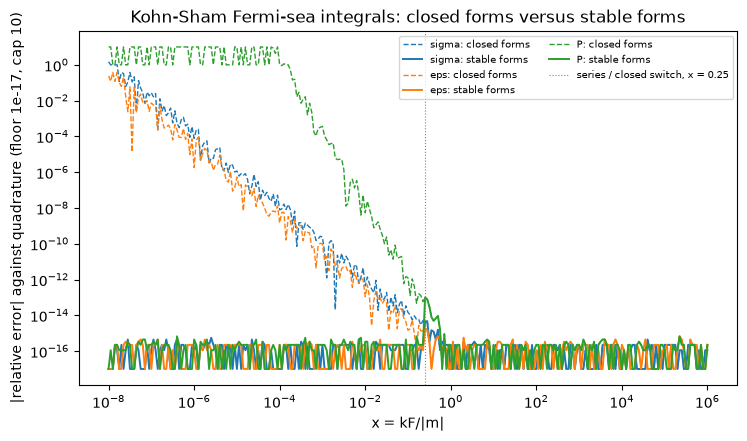


  x = kF/m              sigma rust            sigma python      rel  eps rel    P rel
     1e-08   1.350949115231170e-25   1.350949115231170e-25  3.3e-16  3.3e-16  1.1e-16
     1e-06   1.350949115230765e-19   1.350949115230765e-19  2.2e-16  3.3e-16  2.2e-16
    0.0001   1.350949111178323e-13   1.350949111178323e-13  2.2e-16  0.0e+00  3.3e-16
      0.01   1.350908588928741e-07   1.350908588928741e-07  2.2e-16  0.0e+00  2.2e-16
       0.2   1.068061085384180e-03   1.068061085384180e-03  2.2e-16  0.0e+00  0.0e+00
      0.25   2.072553192245772e-03   2.072553192245771e-03  2.2e-16  5.6e-16  1.3e-14
       0.3   3.553566483770821e-03   3.553566483770830e-03  2.7e-15  3.3e-16  3.1e-14


       0.6   2.652372340977345e-02   2.652372340977345e-02  1.1e-16  0.0e+00  2.2e-16
         1   1.079759539895520e-01   1.079759539895520e-01  2.2e-16  0.0e+00  2.2e-16
         3   1.553939997924673e+00   1.553939997924673e+00  0.0e+00  0.0e+00  2.2e-16
        10   1.975773887150924e+01   1.975773887150924e+01  2.2e-16  4.4e-16  0.0e+00
        99   1.985127528237763e+03   1.985127528237763e+03  2.2e-16  0.0e+00  0.0e+00
       101   2.066180422473183e+03   2.066180422473183e+03  0.0e+00  2.2e-16  1.1e-16
     1e+04   2.026423482292258e+07   2.026423482292258e+07  2.2e-16  2.2e-16  2.2e-16
     1e+06   2.026423672818368e+11   2.026423672818368e+11  0.0e+00  0.0e+00  0.0e+00
largest relative difference Rust - Python over these 15 points: 3.11e-14


In [4]:
xs = np.geomspace(1e-8, 1e6, 281)
acc = []
for x in xs:
    q, s, c = ks_I_quad(x), ks_I_stable(x), ks_I_closed(x)
    rel = lambda u, v: abs(u / v - 1.0) if v != 0 else float('inf')
    acc.append([x] + [rel(s[i], q[i]) for i in range(3)] + [rel(c[i], q[i]) for i in range(3)])
acc = np.array(acc)
worst_stable = acc[:, 1:4].max()
print(f'max relative error of the stable forms against quadrature over 1e-8 <= x <= 1e6: {worst_stable:.2e} '
      f'(at x = {acc[np.unravel_index(acc[:, 1:4].argmax(), acc[:, 1:4].shape)[0], 0]:.3g})')
for x0 in (1e-8, 1e-6, 1e-4, 1e-2, 0.25, 1.0, 1e2, 1e6):
    i = int(np.argmin(np.abs(np.log(xs / x0))))
    print(f'  x = {xs[i]:9.3g}:  stable rel. errors (sigma, eps, P) = {acc[i, 1]:.1e} {acc[i, 2]:.1e} {acc[i, 3]:.1e}   '
          f'closed forms: {acc[i, 4]:.1e} {acc[i, 5]:.1e} {acc[i, 6]:.1e}')
assert worst_stable < 1e-12, 'the stable forms must agree with quadrature to 1e-12'
with open(RESULTS / 'nb05_ks_accuracy.csv', 'w', newline='') as f:
    wr = csv.writer(f)
    wr.writerow(['x', 'rel_err_stable_sigma', 'rel_err_stable_eps', 'rel_err_stable_P', 'rel_err_closed_sigma', 'rel_err_closed_eps', 'rel_err_closed_P'])
    wr.writerows([[f'{v:.10e}' for v in row] for row in acc])

fig, ax = plt.subplots(figsize=(8.5, 4.6))
floor = 1e-17
for i, (lab, col) in enumerate([('sigma', 'tab:blue'), ('eps', 'tab:orange'), ('P', 'tab:green')]):
    ax.loglog(xs, np.clip(acc[:, 4 + i], floor, 10), '--', color=col, lw=1.0, label=f'{lab}: closed forms')
    ax.loglog(xs, np.clip(acc[:, 1 + i], floor, 10), '-', color=col, lw=1.4, label=f'{lab}: stable forms')
ax.axvline(X_SWITCH, color='0.5', lw=0.8, ls=':', label='series / closed switch, x = 0.25')
ax.set_xlabel('x = kF/|m|'); ax.set_ylabel('|relative error| against quadrature (floor 1e-17, cap 10)')
ax.set_title('Kohn-Sham Fermi-sea integrals: closed forms versus stable forms'); ax.legend(fontsize=7, ncol=2)
fig.savefig(RESULTS / 'nb05_ks_accuracy.png', dpi=130, bbox_inches='tight'); print('figure: results/nb05_ks_accuracy.png'); plt.show()

# the same numbers from the Rust solver (mass term, m = 1: sigma8 = sigma_KS, rho8 = eps_KS, P_obs = P_KS)
worst_rust = 0.0
print(f"\n{'x = kF/m':>10s} {'sigma rust':>23s} {'sigma python':>23s} {'rel':>8s} {'eps rel':>8s} {'P rel':>8s}")
for x in (1e-8, 1e-6, 1e-4, 1e-2, 0.2, 0.25, 0.3, 0.6, 1.0, 3.0, 10.0, 99.0, 101.0, 1e4, 1e6):
    r = subprocess.run([str(BIN), 'gap', '--form', 'mass', '--param', 'm0=1', '--kf', repr(x)], check=True, capture_output=True, text=True)
    vals = [l for l in r.stdout.splitlines() if not l.startswith('#') and not l.startswith('m,')][0].split(',')
    s_r, e_r, p_r = float(vals[1]), float(vals[2]), float(vals[3])
    fs = fermi_sea(1.0, x)
    rels = [abs(s_r / fs['sigma'] - 1), abs(e_r / fs['eps'] - 1), abs(p_r / fs['P'] - 1)]
    worst_rust = max(worst_rust, max(rels))
    print(f'{x:10.3g} {s_r:23.15e} {fs["sigma"]:23.15e} {rels[0]:8.1e} {rels[1]:8.1e} {rels[2]:8.1e}')
print(f'largest relative difference Rust - Python over these 15 points: {worst_rust:.2e}')
assert worst_rust < 1e-12

### 5.2 The equation of state of the Fermi sea, `w_KS(x) = P_KS/ε_KS`, from 1/3 to 0

`w_KS` depends on `x = kF/|m|` alone.  For `x → ∞` (ultra-relativistic) `ε_KS → 3P_KS` and
`w_KS → (1/3)(1 − 2/x²)`; for `x → 0` (non-relativistic) `ε_KS → |m| n` and `w_KS → x²/5`.  The cell
evaluates `w_KS` on the same grid, checks that it increases monotonically, and checks both
asymptotic forms; the curve is written to `results/nb05_w_ks.csv` and plotted.  This single function
is the whole equation of state of the author's mass term (`U = W − σW′ = 0`), in the pre-universe
and in the present universe alike.

w_KS at x = 1e-8: 2.000000e-17  (x^2/5 = 2.000000e-17);  at x = 1: 0.121969;  at x = 1e6: 0.333333333332667  (1/3 - 2/(3 x^2) = 0.333333333332667)
max |w_KS/(x^2/5) - 1| for x < 1e-3: 5.22e-07 (the next order is O(x^2));  max |w_KS - (1/3)(1 - 2/x^2)| for x > 1e3: 3.46e-12 (the next order is O(ln x / x^4))


figure: results/nb05_w_ks.png


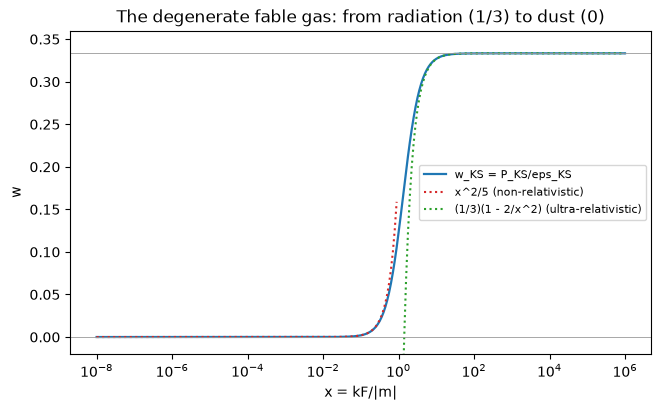

In [5]:
wks = np.array([fermi_sea(1.0, x)['P'] / fermi_sea(1.0, x)['eps'] for x in xs])
print(f'w_KS at x = 1e-8: {wks[0]:.6e}  (x^2/5 = {xs[0] ** 2 / 5:.6e});  at x = 1: {np.interp(0.0, np.log(xs), wks):.6f};  at x = 1e6: {wks[-1]:.15f}  (1/3 - 2/(3 x^2) = {1 / 3 - 2 / (3 * xs[-1] ** 2):.15f})')
assert np.all(np.diff(wks) > 0), 'w_KS increases monotonically with x'
assert abs(wks[0] / (xs[0] ** 2 / 5) - 1) < 1e-6 and abs(wks[-1] - (1 / 3 - 2 / (3 * xs[-1] ** 2))) < 1e-14
small, large = xs < 1e-3, xs > 1e3
nr_dev = np.max(np.abs(wks[small] / (xs[small] ** 2 / 5) - 1))
ur_dev = np.max(np.abs(wks[large] - (1 - 2 / xs[large] ** 2) / 3))
print(f'max |w_KS/(x^2/5) - 1| for x < 1e-3: {nr_dev:.2e} (the next order is O(x^2));  '
      f'max |w_KS - (1/3)(1 - 2/x^2)| for x > 1e3: {ur_dev:.2e} (the next order is O(ln x / x^4))')
assert nr_dev < 1e-5 and ur_dev < 1e-10
with open(RESULTS / 'nb05_w_ks.csv', 'w', newline='') as f:
    wr = csv.writer(f); wr.writerow(['x', 'w_KS']); wr.writerows([[f'{a:.10e}', f'{b:.15e}'] for a, b in zip(xs, wks)])
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.semilogx(xs, wks, lw=1.6, label='w_KS = P_KS/eps_KS')
ax.semilogx(xs[xs < 1], xs[xs < 1] ** 2 / 5, ':', color='tab:red', label='x^2/5 (non-relativistic)')
ax.semilogx(xs[xs > 1], (1 - 2 / xs[xs > 1] ** 2) / 3, ':', color='tab:green', label='(1/3)(1 - 2/x^2) (ultra-relativistic)')
ax.axhline(1 / 3, color='0.6', lw=0.6); ax.axhline(0, color='0.6', lw=0.6)
ax.set_ylim(-0.02, 0.36); ax.set_xlabel('x = kF/|m|'); ax.set_ylabel('w'); ax.legend(fontsize=8)
ax.set_title('The degenerate fable gas: from radiation (1/3) to dust (0)')
fig.savefig(RESULTS / 'nb05_w_ks.png', dpi=130, bbox_inches='tight'); print('figure: results/nb05_w_ks.png'); plt.show()

### 5.3 The thermodynamic identities

At zero temperature the chemical potential is `wF`, and the Fermi sea obeys, for every `x` and both
signs of `m`:

    ε_KS − 3 P_KS = m σ_KS            (the trace identity; T_s := ε_KS − m σ_KS = 3 P_KS)
    ε_KS + P_KS  = wF n               (Gibbs–Duhem, μ = wF)
    ∂ε_KS/∂n |_m = wF ,   ∂ε_KS/∂m |_kF = σ_KS      (the first law  dε = wF dn + σ dm)
    χ = ∂σ_KS/∂m |_kF > 0,  χ ≤ χ0 = g kF²/(4π²)

The first law is what makes the self-consistent fluid conserve energy exactly: at a gap root the
`σ dm` terms cancel, so `dρ = wF dn`, and `ρ + P_obs = wF n ≥ 0` for **every** potential — the
quantized fable cannot have `w < −1` where `ρ > 0`.  The cell checks each identity on 41 values of
`x` from `1e−4` to `1e4` for `m = ±1.3`; the derivatives by central differences (step `1e−5`
relative) on the points with `1e−2 ≤ x ≤ 1e2` (outside that range a difference of the energy
cannot resolve `σ dm`: for `x ≫ 1` the change `σ h` is below the rounding of `ε ∝ kF⁴`, for `x ≪ 1`
the change of `σ ≈ n` with `m` is below the rounding of `n`).  The largest residuals go to
`results/nb05_identities.csv`.

In [6]:
ident = {'eps - 3P - m sigma (rel. to eps)': 0.0, 'eps + P - wF n (rel.)': 0.0, 'd eps/dn|m - wF (rel.)': 0.0,
         'd eps/dm|kF - sigma (rel.)': 0.0, 'chi - d sigma/dm (rel.)': 0.0, 'max chi/chi0': 0.0}
for m in (1.3, -1.3):
    for x in np.geomspace(1e-4, 1e4, 41):
        kf = x * abs(m)
        s = fermi_sea(m, kf)
        ident['eps - 3P - m sigma (rel. to eps)'] = max(ident['eps - 3P - m sigma (rel. to eps)'], abs(s['eps'] - 3 * s['P'] - m * s['sigma']) / s['eps'])
        ident['eps + P - wF n (rel.)'] = max(ident['eps + P - wF n (rel.)'], abs((s['eps'] + s['P']) / (s['wF'] * s['n']) - 1))
        ident['max chi/chi0'] = max(ident['max chi/chi0'], s['chi'] / (G_FABLE * kf * kf / (4 * PI2)))
        if not 1e-2 <= x <= 1e2:
            continue                                   # central differences: only where they resolve the derivative
        h = 1e-5 * kf
        sp, sm = fermi_sea(m, kf + h), fermi_sea(m, kf - h)
        ident['d eps/dn|m - wF (rel.)'] = max(ident['d eps/dn|m - wF (rel.)'], abs((sp['eps'] - sm['eps']) / (sp['n'] - sm['n']) / s['wF'] - 1))
        hm = 1e-5 * abs(m)
        mp, mm = fermi_sea(m + hm, kf), fermi_sea(m - hm, kf)
        ident['d eps/dm|kF - sigma (rel.)'] = max(ident['d eps/dm|kF - sigma (rel.)'], abs((mp['eps'] - mm['eps']) / (2 * hm) / s['sigma'] - 1))
        ident['chi - d sigma/dm (rel.)'] = max(ident['chi - d sigma/dm (rel.)'], abs((mp['sigma'] - mm['sigma']) / (2 * hm) / s['chi'] - 1))
for k, v in ident.items():
    print(f'{k:36s} {v:.2e}')
assert ident['eps - 3P - m sigma (rel. to eps)'] < 1e-13 and ident['eps + P - wF n (rel.)'] < 1e-13
assert ident['d eps/dn|m - wF (rel.)'] < 1e-8 and ident['d eps/dm|kF - sigma (rel.)'] < 1e-7 and ident['chi - d sigma/dm (rel.)'] < 1e-6
assert ident['max chi/chi0'] <= 1.0 + 1e-12
with open(RESULTS / 'nb05_identities.csv', 'w', newline='') as f:
    wr = csv.writer(f); wr.writerow(['identity', 'largest_residual']); wr.writerows([[k, f'{v:.3e}'] for k, v in ident.items()])
print('written: results/nb05_identities.csv')

eps - 3P - m sigma (rel. to eps)     1.53e-15
eps + P - wF n (rel.)                5.55e-16
d eps/dn|m - wF (rel.)               7.44e-11
d eps/dm|kF - sigma (rel.)           3.61e-08
chi - d sigma/dm (rel.)              2.63e-07
max chi/chi0                         1.00e+00
written: results/nb05_identities.csv


### 5.4 The non-relativistic limit is Part VI's classical fable — except for the phantom crossing

For `kF ≪ |m|` the Fermi sea expands as `σ_KS = sgn(m) n [1 − (3/10) x² + …]`,
`ε_KS = |m| n [1 + (3/10) x² + …]` and `P_KS = n kF²/(5|m|) [1 + …]`, so the mean-field fluid becomes

    ρ → W(sgn(m) n) + (3/10) n kF²/|m| ,     P_obs → [σW′ − W] + n kF²/(5|m|) ,     P_hid = σW′ − W ,

which is Part VI's classical `ρ = V(s)`, `P = sV′ − V`, `w = sV′/V − 1` with `s = Hσ` (its `K_h = 0`
branch).  Self-consistency forces `sgn σ = sgn m = sgn W′`, which removes Part VI's branch with
`M s > 0`; for the author's `W = −2Mσ`, `ρ → 2|M| n > 0`.  The first cell checks the three
expansion coefficients.  The second compares, for five of Part VI's potential shapes (`mass`
`V = s`; `lambda-mass` `V = 0.7 + 0.3 s`; `power` `V = s + s^0.236`; `expdamp`
`V = 1.566 + 0.839 s e^{−s/2.21}`; `lorentz` `V = 1 + s/(1 + (s/1.5)²)`), the classical
`w_cl(s = n)` with the quantum `w = P_obs/ρ` of the lowest-energy gap root at density `n`, for
`W = A V` with `A = 10⁴, 10², 1`: a large `A` makes the quasiparticles heavy (`m = A V′`), which is
the classical limit.  Below the classical crossing the quantum `w` approaches `w_cl` as `A` grows.
Where the classical `w_cl` drops below −1 (`expdamp` and `lorentz` for `s > s1`, where `V′ < 0`),
the quantum theory does **not** follow: the gap pins `σ` below `min(n, s1)`, the quasiparticles become
light and relativistic, and `w ≥ −1` at every root.

In [7]:
x = 1e-3
s = fermi_sea(2.0, 2.0 * x)
c_sigma = (s['sigma'] / s['n'] - 1) / x ** 2
c_eps = (s['eps'] / (2.0 * s['n']) - 1) / x ** 2
c_P = s['P'] / (s['n'] * (2.0 * x) ** 2 / 2.0)
print(f'at x = {x:g}: (sigma/n - 1)/x^2 = {c_sigma:+.6f} (-3/10),  (eps/(|m| n) - 1)/x^2 = {c_eps:+.6f} (+3/10),  P/(n kF^2/|m|) = {c_P:.6f} (1/5)')
assert abs(c_sigma + 0.3) < 1e-5 and abs(c_eps - 0.3) < 1e-5 and abs(c_P - 0.2) < 1e-5
s = fermi_sea(-2.0, 2.0 * x)
print(f'm = -2: sigma/n = {s["sigma"] / s["n"]:+.9f}: sgn(sigma) = sgn(m)')
assert s['sigma'] < 0

at x = 0.001: (sigma/n - 1)/x^2 = -0.300000 (-3/10),  (eps/(|m| n) - 1)/x^2 = +0.300000 (+3/10),  P/(n kF^2/|m|) = 0.200000 (1/5)
m = -2: sigma/n = -0.999999700: sgn(sigma) = sgn(m)


Now the comparison over densities `1e−3 ≤ n ≤ 30` (in units where the classical `s` equals `n`).
For every density and every `A` the cell finds all gap roots, takes the one of lowest `ρ`, and
records the quantum `w`, `σ/n`, `x = kF/|m|` and the number of roots; the classical `w_cl` is exact.
The assertions: `ρ + P_obs = wF n ≥ 0` at every root found (so `w ≥ −1` wherever `ρ > 0`); for
`expdamp`, `0 < σ < min(n, s1)` at every density; the classical `w_cl` of `expdamp` and `lorentz`
is below −1 at some density; and, below half the crossing density, the largest `|w − w_cl|` shrinks
as `A` grows.  The table goes to `results/nb05_classical_vs_quantum.csv`.

915 (potential, A, n) points in 2.9 s
mass         classical: min w_cl = +0.0000, never crosses -1 | A=10000: min w = +0.00000, max|w-w_cl| (n < half crossing) = 4.14e-08 | A=100: min w = +0.00000, max|w-w_cl| (n < half crossing) = 4.13e-04 | A=1: min w = +0.00741, max|w-w_cl| (n < half crossing) = 3.05e-01
lambda-mass  classical: min w_cl = -0.9996, never crosses -1 | A=10000: min w = -0.99957, max|w-w_cl| (n < half crossing) = 4.79e-07 | A=100: min w = -0.99957, max|w-w_cl| (n < half crossing) = 4.72e-03 | A=1: min w = -0.99949, max|w-w_cl| (n < half crossing) = 6.54e-01
power        classical: min w_cl = -0.7601, never crosses -1 | A=10000: min w = -0.76012, max|w-w_cl| (n < half crossing) = 4.13e-08 | A=100: min w = -0.76012, max|w-w_cl| (n < half crossing) = 4.13e-04 | A=1: min w = -0.76012, max|w-w_cl| (n < half crossing) = 3.70e-01
expdamp      classical: min w_cl = -1.3020, crosses -1 at n = 2.2047 | A=10000: min w = -0.99952, max|w-w_cl| (n < half crossing) = 4.61e-08 | A=100:

figure: results/nb05_classical_vs_quantum.png


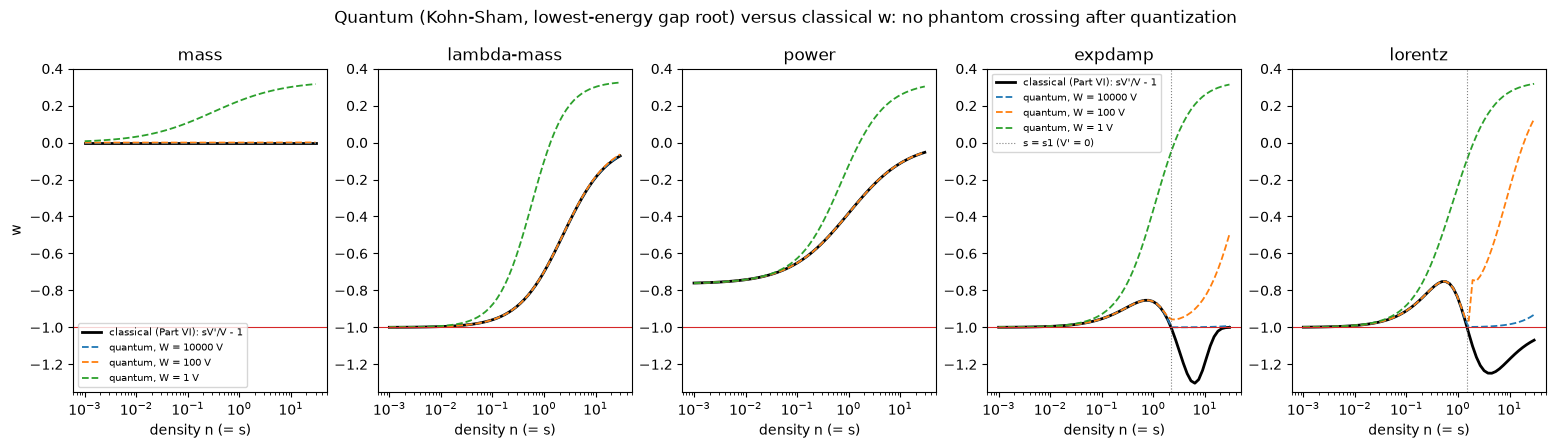

In [8]:
SHAPES = {'mass': Pot('mass', m0=1.0), 'lambda-mass': Pot('lambda-mass', v0=0.7, m0=0.3), 'power': Pot('power', m0=1.0, lam=1.0, nu=0.236),
          'expdamp': Pot('expdamp', v0=1.566, m0=0.839, s1=2.21), 'lorentz': Pot('lorentz', v0=1.0, m0=1.0, s1=1.5)}
AS = [1e4, 1e2, 1.0]
ns = np.geomspace(1e-3, 30.0, 61)
cq_rows, curves = [], {}
t0 = time.time()
for name, V in SHAPES.items():
    wcl = np.array([n * V.dW(n) / V.W(n) - 1.0 for n in ns])
    curves[(name, 'classical')] = wcl
    for A in AS:
        W = V.scaled(A)
        wq, son, xr = [], [], []
        for n in ns:
            kf = (6 * PI2 * n / G_FABLE) ** (1 / 3)
            roots = gap_roots(W, kf, ngrid=1201)
            mfs = [mean_field(W, m, kf) for m in roots]
            for d in mfs:                                   # rho + P_obs = wF n >= 0 on EVERY root
                assert abs((d['rho'] + d['P_obs']) / (d['wF'] * d['n8']) - 1) < 1e-9 and d['rho'] + d['P_obs'] >= 0
            b = min(mfs, key=lambda d: d['rho'])
            if name == 'expdamp':
                assert 0 < b['sigma8'] < min(n, V.p['s1']), (n, b['sigma8'])
            w = b['P_obs'] / b['rho']
            if b['rho'] > 0:
                assert w >= -1 - 1e-12
            wq.append(w); son.append(b['sigma8'] / n); xr.append(kf / abs(b['m']) if b['m'] != 0 else float('inf'))
            cq_rows.append(dict(potential=name, A=A, n=n, w_classical=float(V.dW(n) * n / V.W(n) - 1), w_quantum=w, sigma_over_n=b['sigma8'] / n,
                                x_kF_over_m=xr[-1], n_roots=len(roots), rho_over_A=b['rho'] / A))
        curves[(name, A)] = (np.array(wq), np.array(son), np.array(xr))
print(f'{len(cq_rows)} (potential, A, n) points in {time.time() - t0:.1f} s')
for name in SHAPES:
    wcl = curves[(name, 'classical')]
    cross = crossing_points(ns, wcl, -1.0)
    line = f'{name:12s} classical: min w_cl = {wcl.min():+.4f}' + (f', crosses -1 at n = {", ".join(f"{c:.4f}" for c in cross)}' if cross else ', never crosses -1')
    for A in AS:
        wq = curves[(name, A)][0]
        below = ns < 0.5 * (cross[0] if cross else ns[-1])
        line += f' | A={A:g}: min w = {wq.min():+.5f}, max|w-w_cl| (n < half crossing) = {np.max(np.abs(wq[below] - wcl[below])):.2e}'
    print(line)
for name in ('expdamp', 'lorentz'):
    assert curves[(name, 'classical')].min() < -1.0, f'the classical {name} crosses the phantom divide'
    devs = [np.max(np.abs(curves[(name, A)][0][ns < 0.5 * crossing_points(ns, curves[(name, "classical")], -1.0)[0]] -
                          curves[(name, 'classical')][ns < 0.5 * crossing_points(ns, curves[(name, "classical")], -1.0)[0]])) for A in AS]
    assert devs[0] < devs[1] < devs[2], f'{name}: the quantum w approaches the classical one as A grows'
print('the quantum w >= -1 at every density, every A and every potential; the classical expdamp and lorentz cross -1')
with open(RESULTS / 'nb05_classical_vs_quantum.csv', 'w', newline='') as f:
    wr = csv.DictWriter(f, fieldnames=list(cq_rows[0].keys())); wr.writeheader()
    wr.writerows([{k: (f'{v:.10g}' if isinstance(v, float) else v) for k, v in r.items()} for r in cq_rows])
print('written: results/nb05_classical_vs_quantum.csv')

fig, axes = plt.subplots(1, 5, figsize=(19, 4.2), sharey=False)
for ax, name in zip(axes, SHAPES):
    ax.semilogx(ns, curves[(name, 'classical')], 'k-', lw=2.0, label='classical (Part VI): sV\'/V - 1')
    for A, col in zip(AS, ('tab:blue', 'tab:orange', 'tab:green')):
        ax.semilogx(ns, curves[(name, A)][0], '--', color=col, lw=1.3, label=f'quantum, W = {A:g} V')
    ax.axhline(-1.0, color='tab:red', lw=0.8)
    if name in ('expdamp', 'lorentz'):
        ax.axvline(SHAPES[name].p['s1'], color='0.5', ls=':', lw=0.8, label='s = s1 (V\' = 0)')
    ax.set_title(name); ax.set_xlabel('density n (= s)'); ax.set_ylim(-1.35, 0.4)
axes[0].set_ylabel('w'); axes[0].legend(fontsize=7, loc='lower left'); axes[3].legend(fontsize=7, loc='upper left')
fig.suptitle('Quantum (Kohn-Sham, lowest-energy gap root) versus classical w: no phantom crossing after quantization', y=1.02)
fig.savefig(RESULTS / 'nb05_classical_vs_quantum.png', dpi=130, bbox_inches='tight'); print('figure: results/nb05_classical_vs_quantum.png'); plt.show()

### 5.5 The gap equation: the uniqueness criterion, three roots, and a first-order jump

For the repulsive quadratic `W = m0 σ + (λ/2) σ²` with `(m0, λ) = (0.05, 20)`, `W″ χ0 = λ g kF²/(4π²)`
passes 1 at the `kF = Sqrt[4π²/(λ g)]` that the cell prints; above it the uniqueness argument no longer applies.  At `kF = 1` the
cell plots `f(m) = m − W′(σ_KS(m))`, finds its roots with the Python gap solver, and compares the
roots and their `ρ`, `P_obs`, `P_hid` with the Rust solver's `gap` command.  It checks
`ρ + P_obs = wF n` on each root (so `w ≥ −1` on every branch) and marks the lowest-energy root, the
ground state.  It then follows the ground state as `kF` grows from 0.2 to 2: where the three roots
appear, the lowest-energy root jumps from the positive-mass branch to the negative-mass branch — a
first-order transition, which is why the solver refuses a repulsive quadratic run (energy
conservation would need a Maxwell construction).  At `kF = 0.4`, below the criterion, the root is
unique.  The data go to `results/nb05_gap_roots.csv`.

kF = 1.0: W'' chi0 = lam g kF^2/(4 pi^2) = 4.0528 > 1;  3 roots
# potential Quadratic { v0: 0.0, m0: 0.05, lam: 20.0 }, kF = 1e0, v = 1e0, n8 = 1.3509491152311703e-1, plan = Scan { lo: -2.651898230462341, hi: 2.7518982304623405 }
m,sigma8,rho8,P_obs,P_hid,gap_residual
-2.535353916022531e0,-1.292676958011266e-1,1.909782056219713e-1,1.772147779888931e-1,1.671013717773260e-1,8.506e-17
-1.640336879334347e-2,-3.320168439667173e-3,1.012381942988485e-1,3.387489103006236e-2,1.102351846776195e-4,-1.898e-17
2.644093986040535e0,1.297046993020268e-1,2.039272771420881e-1,1.779694075325236e-1,1.682330902102918e-1,0.000e0
# selected (Lowest): m = -1.640336879334347e-2, rho8 = 1.012381942988485e-1, roots = 3

            m (python)               m (rust)     rho python rel. diff P_obs rel P_hid rel (rho+P)/(wF n)  ground state
-2.535353916022532e+00 -2.535353916022531e+00   0.1909782056   1.3e-15   2.2e-15   1.1e-15 1.000000000000  
-1.640336879334347e-02 -1.640336879334347e-02   0.1012381943   4.4e-1

uniqueness criterion lam chi0 < 1 holds for kF < 0.4967; three roots first appear at kF = 0.625 on this grid; the ground state jumps from m = +0.4756 (kF = 0.600) to m = -0.0998 (kF = 0.625)
kF = 0.4: lam chi0 = 0.648 < 1 and 1 root (m = 0.1159541205)
figure: results/nb05_gap_roots.png


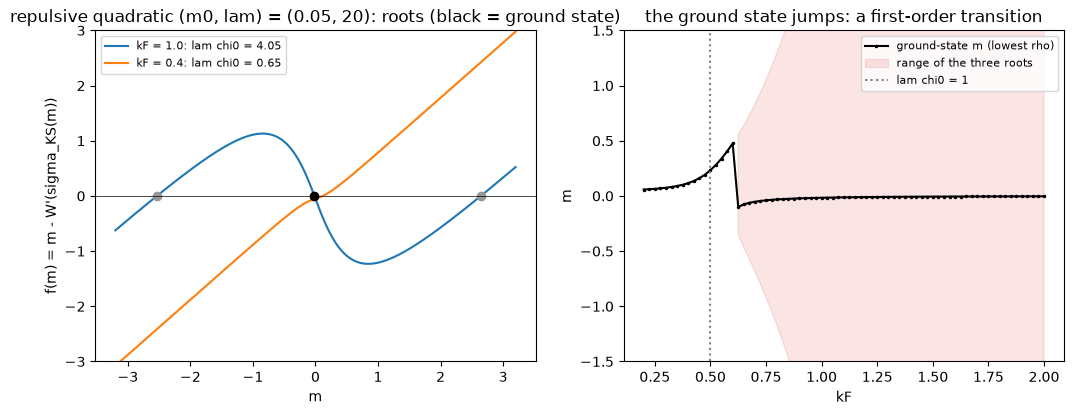

In [9]:
Wrep = Pot('quadratic', v0=0.0, m0=0.05, lam=20.0)
kf = 1.0
chi0 = G_FABLE * kf * kf / (4 * PI2)
roots = gap_roots(Wrep, kf)
mfs = [mean_field(Wrep, m, kf) for m in roots]
gs = min(mfs, key=lambda d: d['rho'])
print(f'kF = {kf}: W\'\' chi0 = lam g kF^2/(4 pi^2) = {20 * chi0:.4f} > 1;  {len(roots)} roots')
r = subprocess.run([str(BIN), 'gap', '--form', 'quadratic', '--param', 'm0=0.05', '--param', 'lam=20', '--kf', '1'], check=True, capture_output=True, text=True)
print(r.stdout)
rust_rows = [list(map(float, l.split(','))) for l in r.stdout.splitlines() if l and not l.startswith('#') and not l.startswith('m,')]
assert len(rust_rows) == len(roots) == 3
print(f"{'m (python)':>22s} {'m (rust)':>22s} {'rho python':>14s} {'rel. diff':>9s} {'P_obs rel':>9s} {'P_hid rel':>9s} {'(rho+P)/(wF n)':>14s}  ground state")
for d, rr in zip(mfs, rust_rows):
    dr = [abs(d['m'] / rr[0] - 1), abs(d['rho'] / rr[2] - 1), abs(d['P_obs'] / rr[3] - 1), abs(d['P_hid'] / rr[4] - 1)]
    assert max(dr) < 1e-10, dr
    print(f"{d['m']:22.15e} {rr[0]:22.15e} {d['rho']:14.10f} {dr[1]:9.1e} {dr[2]:9.1e} {dr[3]:9.1e} {(d['rho'] + d['P_obs']) / (d['wF'] * d['n8']):14.12f}  {'<-- lowest rho' if d is gs else ''}")
rust_sel = float(re.search(r'm = ([-+0-9.e]+)', [l for l in r.stdout.splitlines() if l.startswith('# selected')][0]).group(1))
assert abs(rust_sel / gs['m'] - 1) < 1e-10, 'the Rust solver selects the same (lowest-energy) root'
print(f'both codes select m = {gs["m"]:.12e} (rho = {gs["rho"]:.12f})')

scan = []
for kf_s in np.linspace(0.2, 2.0, 73):
    rs = gap_roots(Wrep, kf_s)
    b = min((mean_field(Wrep, m, kf_s) for m in rs), key=lambda d: d['rho'])
    scan.append((kf_s, 20 * G_FABLE * kf_s ** 2 / (4 * PI2), len(rs), b['m'], b['rho'], min(rs), max(rs)))
scan = np.array(scan)
k_three = scan[scan[:, 2] == 3, 0].min()
jump = np.argmax(np.sign(scan[:, 3]) < 0)
print(f'uniqueness criterion lam chi0 < 1 holds for kF < {math.sqrt(4 * PI2 / (20 * G_FABLE)):.4f}; three roots first appear at kF = {k_three:.3f} on this grid; '
      f'the ground state jumps from m = {scan[jump - 1, 3]:+.4f} (kF = {scan[jump - 1, 0]:.3f}) to m = {scan[jump, 3]:+.4f} (kF = {scan[jump, 0]:.3f})')
assert scan[scan[:, 1] < 1, 2].max() == 1, 'below the criterion the root is unique'
r04 = gap_roots(Wrep, 0.4)
print(f'kF = 0.4: lam chi0 = {20 * G_FABLE * 0.16 / (4 * PI2):.3f} < 1 and {len(r04)} root (m = {r04[0]:.10f})')
with open(RESULTS / 'nb05_gap_roots.csv', 'w', newline='') as f:
    wr = csv.writer(f); wr.writerow(['kF', 'lam_chi0', 'n_roots', 'm_ground', 'rho_ground', 'm_min_root', 'm_max_root'])
    wr.writerows([[f'{v:.10g}' for v in row] for row in scan])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.3))
mgrid = np.linspace(-3.2, 3.2, 1601)
for kf_p, col in ((1.0, 'tab:blue'), (0.4, 'tab:orange')):
    ax1.plot(mgrid, [gap_function(Wrep, m, kf_p) for m in mgrid], color=col, label=f'kF = {kf_p}: lam chi0 = {20 * G_FABLE * kf_p ** 2 / (4 * PI2):.2f}')
for d in mfs:
    ax1.plot(d['m'], 0, 'o', color='k' if d is gs else '0.6', ms=6)
ax1.axhline(0, color='k', lw=0.5); ax1.set_xlabel('m'); ax1.set_ylabel("f(m) = m - W'(sigma_KS(m))"); ax1.set_ylim(-3, 3)
ax1.set_title('repulsive quadratic (m0, lam) = (0.05, 20): roots (black = ground state)'); ax1.legend(fontsize=8)
ax2.plot(scan[:, 0], scan[:, 3], 'k.-', ms=3, label='ground-state m (lowest rho)')
ax2.fill_between(scan[:, 0], scan[:, 5], scan[:, 6], where=scan[:, 2] == 3, color='tab:red', alpha=0.12, label='range of the three roots')
ax2.axvline(math.sqrt(4 * PI2 / (20 * G_FABLE)), color='0.5', ls=':', label='lam chi0 = 1')
ax2.set_xlabel('kF'); ax2.set_ylabel('m'); ax2.set_ylim(-1.5, 1.5); ax2.legend(fontsize=8); ax2.set_title('the ground state jumps: a first-order transition')
fig.savefig(RESULTS / 'nb05_gap_roots.png', dpi=130, bbox_inches='tight'); print('figure: results/nb05_gap_roots.png'); plt.show()

### 5.6 The no-sea functional is a minimax; the Walecka functional is convex for attractive `W`

The Kohn–Sham energy of the gas at fixed `n` as a functional of the scalar density,
`E_n[σ] = T_s(σ; n) + W(σ)` with `T_s = ε_KS(m(σ)) − m(σ) σ` and `m(σ)` defined by `σ_KS(m, kF) = σ`,
has `dE_n/dσ = W′(σ) − m(σ)` (stationary exactly at the gap roots) and `d²T_s/dσ² = −1/χ < 0`: the
kinetic part is **concave**.  For the mass term the physical root is therefore a **maximum** of
`E_n` over `σ ∈ (−n, n)`, and the infimum is the variational collapse `E_n → −|m0| n` as `σ → −n`
(every particle in the negative-mass band, i.e. in states of the Dirac sea).  The ground state is a
stationary point of this minimax functional (a maximum in `σ`, a minimum in the occupations), never
its minimum over `σ`.  For attractive (concave) `W` the auxiliary-field **Walecka functional**
`Ω_n(m) = ε_KS(m) + W(σ_m) − m σ_m`, `W′(σ_m) = m`, is convex, its minimum is the gap root, and
`Ω_n(m*) = ρ`.  The cell draws both, for `W = 2σ` at `kF = 1.5` and `W = σ − 10σ²` at `kF = 1`, and
writes the curves to `results/nb05_minimax.csv`.

mass term W = 2 sigma, kF = 1.5: n = 0.4559453264, the gap root sigma* = 0.3961298703 (sigma*/n = 0.868810)
E_n(sigma*) = 1.052962422118 = rho = eps_KS(m0) = 1.052962422118;  max of E_n over the grid = 1.052959281278
E_n/n at sigma = -(1 - 1e-7) n: -1.999480  (the collapse value -|m0| = -2.0)

attractive W = sigma - 10 sigma^2, kF = 1: unique gap root m* = 0.2112489356, rho = 0.1211932853;  Omega_n(m*) = 0.121193285306
Omega_n on the grid: minimum 0.121193451922 at m = 0.2100;  second differences all positive (convex): True
figure: results/nb05_minimax.png


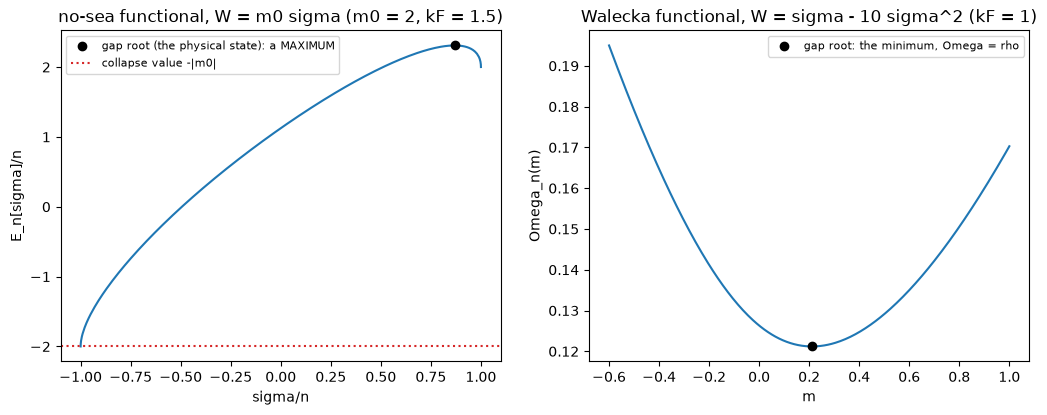

In [10]:
def m_of_sigma(s, kf):
    """The m with sigma_KS(m, kF) = s (sigma_KS is odd, increasing and maps R onto (-n, n))."""
    f = lambda m: fermi_sea(m, kf)['sigma'] - s
    hi, lo = kf, -kf
    while f(hi) < 0:
        hi *= 2
    while f(lo) > 0:
        lo *= 2
    return brentq(f, lo, hi, xtol=1e-300, rtol=1e-15, maxiter=500)


def E_n(pot, s, kf):
    m = m_of_sigma(s, kf)
    fs = fermi_sea(m, kf)
    return fs['eps'] - m * s + pot.W(s)


Wm, kfm = Pot('mass', m0=2.0), 1.5
n_m = G_FABLE * kfm ** 3 / (6 * PI2)
s_star = fermi_sea(2.0, kfm)['sigma']
E_star = E_n(Wm, s_star, kfm)
fr = np.concatenate([-1 + np.geomspace(1e-7, 1e-2, 25), np.linspace(-0.99, 0.99, 199), 1 - np.geomspace(1e-2, 1e-7, 25)])
E_curve = np.array([E_n(Wm, f_ * n_m, kfm) for f_ in fr])
print(f'mass term W = 2 sigma, kF = {kfm}: n = {n_m:.10f}, the gap root sigma* = {s_star:.10f} (sigma*/n = {s_star / n_m:.6f})')
print(f'E_n(sigma*) = {E_star:.12f} = rho = eps_KS(m0) = {fermi_sea(2.0, kfm)["eps"]:.12f};  max of E_n over the grid = {E_curve.max():.12f}')
print(f'E_n/n at sigma = -(1 - 1e-7) n: {E_curve[0] / n_m:+.6f}  (the collapse value -|m0| = {-2.0:+.1f})')
h = 1e-4 * n_m
assert E_n(Wm, s_star + h, kfm) < E_star and E_n(Wm, s_star - h, kfm) < E_star and E_curve.max() <= E_star + 1e-12
assert abs(E_star / fermi_sea(2.0, kfm)['eps'] - 1) < 1e-12 and abs(E_curve[0] / n_m + 2.0) < 1e-2

Wa, kfa = Pot('quadratic', v0=0.0, m0=1.0, lam=-20.0), 1.0
ra = gap_roots(Wa, kfa)
assert len(ra) == 1
ga = mean_field(Wa, ra[0], kfa)
Om = lambda m: fermi_sea(m, kfa)['eps'] + Wa.W((m - 1.0) / -20.0) - m * (m - 1.0) / -20.0
mg = np.linspace(-0.6, 1.0, 321)
Om_curve = np.array([Om(m) for m in mg])
print(f'\nattractive W = sigma - 10 sigma^2, kF = 1: unique gap root m* = {ra[0]:.10f}, rho = {ga["rho"]:.10f};  Omega_n(m*) = {Om(ra[0]):.12f}')
print(f'Omega_n on the grid: minimum {Om_curve.min():.12f} at m = {mg[Om_curve.argmin()]:.4f};  second differences all positive (convex): {bool(np.all(np.diff(Om_curve, 2) > 0))}')
assert abs(Om(ra[0]) / ga['rho'] - 1) < 1e-12 and np.all(np.diff(Om_curve, 2) > 0) and Om_curve.min() >= Om(ra[0]) - 1e-14
with open(RESULTS / 'nb05_minimax.csv', 'w', newline='') as f:
    wr = csv.writer(f); wr.writerow(['curve', 'abscissa', 'value'])
    wr.writerows([['E_n(sigma)/n, W=2 sigma, kF=1.5; abscissa sigma/n', f'{a:.10g}', f'{b / n_m:.12g}'] for a, b in zip(fr, E_curve)])
    wr.writerows([['Omega_n(m), W=sigma-10 sigma^2, kF=1; abscissa m', f'{a:.10g}', f'{b:.12g}'] for a, b in zip(mg, Om_curve)])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.3))
ax1.plot(fr, E_curve / n_m, lw=1.5); ax1.plot(s_star / n_m, E_star / n_m, 'ko', label='gap root (the physical state): a MAXIMUM')
ax1.axhline(-2.0, color='tab:red', ls=':', label='collapse value -|m0|'); ax1.set_xlabel('sigma/n'); ax1.set_ylabel('E_n[sigma]/n')
ax1.set_title('no-sea functional, W = m0 sigma (m0 = 2, kF = 1.5)'); ax1.legend(fontsize=8)
ax2.plot(mg, Om_curve, lw=1.5); ax2.plot(ra[0], Om(ra[0]), 'ko', label='gap root: the minimum, Omega = rho')
ax2.set_xlabel('m'); ax2.set_ylabel('Omega_n(m)'); ax2.set_title('Walecka functional, W = sigma - 10 sigma^2 (kF = 1)'); ax2.legend(fontsize=8)
fig.savefig(RESULTS / 'nb05_minimax.png', dpi=130, bbox_inches='tight'); print('figure: results/nb05_minimax.png'); plt.show()

### 5.7 On the pre-universe: the charge is conserved per coordinate volume, the gas cools from 1/3 to 0

On the canonical frame `Sqrt[|det g|] = Sec[6Hx0]` does not depend on `x4`, so the conserved number
`N = ∫ Sqrt[|g|] n⁴` fixes the density per *coordinate* volume for all `x4`: the 8-density does not
dilute.  A mode with coordinate momentum `k` along `x1` has the physical momentum
`k/q = k e^{a4} Sin[6Hx0]^{1/6}`, so at fixed `x0` every observed-sheet momentum — and the Fermi
momentum — scales as `e^{a4} = 1/a` with `a := e^{−a4}` (the observed sheet grows while the hidden
timelike sheet shrinks, the 7-volume staying fixed).  For the author's mass term `W = −2Mσ`
(`|m| = 2|M|`, `U = 0`) the equation of state is `w_KS(x)` at `x = kF/|m| = a_nr/a`, with `a_nr` the
value of `a` at which `kF = |m|`: the quantum gas cools from `w = 1/3` to `w = 0` as `a4` decreases,
whereas the classical fable of Part VI has `ds/dx4 = 0` and a frozen `w = sV′/V − 1` (`= 0` for the
mass term).  `a4` itself is never given a value: the curve is plotted against `a/a_nr`.  The cell
checks the frame statements numerically at random `(x0, a4)`, then compares `w_KS(a_nr/a)` with the
Rust solver's `fable4d` run of the mass term (`m0 = 30 eV`), whose quasiparticle column `w_qp` is the
same function of `kF0/(A m)`; the sign of `m` does not enter (`ε`, `P` are even in `m`).

195 grid points (x0, a4), H = 0.37: max |Sqrt|det g| Cos[6Hx0] - 1| and max |(k/q)/(k e^a4 Sin^(1/6)) - 1| = 2.3e-15
$ fable_fermion fable4d --potential mass --param m0_ev=30 --points 1001 --out results/nb05_fable4d_mass30.csv
  # normalization: closure today (A = B = C = 1): rho_r + rho_b + rho_f = 1; shooting variable [ln kF0 (the fable number density)] = -2.485515249891274e0; rho_f(A=1; kF0) strictly increasing on the Lowest branch over ln kF0 in [-40, 40] (1601 grid points, 0 without a gap solution); unique solution ln kF0 = -2.485515249891274e0
  # fable today (A = 1, v = 1): potential Mass { m0: 12182.181219597018 }, kF0 = 8.3282632088e-2 E_c = 2.050929e-4 eV, m_eff = 1.2182181220e4 E_c = 3.000000e1 eV, rho_qp = 9.5066471258e-1, U = 0.0000000000e0, rho_f = 9.5066471258e-1, w_f = 9.3473556871e-12, gap roots = 1
  # result: H_A(A=1) = 1.000000000000000e0, B(1) = 1.000000000000000e0, C(1) = 1.000000000000000e0, q0 = 5.000460e-1, age t0 = 6.6660643059e-1/H0, max |constraint residual|

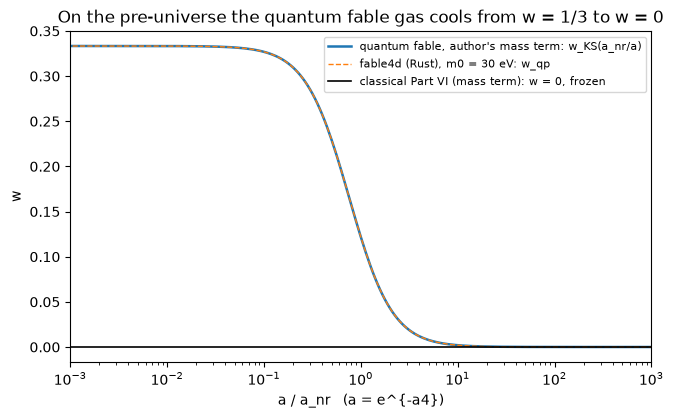

In [11]:
Hc = 0.37
worst, npts = 0.0, 0
for u6, a4 in itertools.product(np.linspace(0.01, 0.99, 15), np.linspace(-3.0, 3.0, 13)):
    x0 = u6 * math.pi / (12 * Hc)                   # 6 H x0 = u6 pi/2 in (0, pi/2)
    npts += 1
    S, C = math.sin(6 * Hc * x0), math.cos(6 * Hc * x0)
    q, p = math.exp(-a4) / S ** (1 / 6), math.exp(a4) / S ** (1 / 6)
    g = np.diag([(S / C) ** 2, q * q, q * q, q * q, -1.0, -p * p, -p * p, -p * p])
    worst = max(worst, abs(math.sqrt(abs(np.linalg.det(g))) * C - 1.0), abs((1.0 / q) / (math.exp(a4) * S ** (1 / 6)) - 1.0))
print(f'{npts} grid points (x0, a4), H = {Hc}: max |Sqrt|det g| Cos[6Hx0] - 1| and max |(k/q)/(k e^a4 Sin^(1/6)) - 1| = {worst:.1e}')
assert worst < 1e-12

run = run_fermion('nb05_fable4d_mass30', 'fable4d', '--potential', 'mass', '--param', 'm0_ev=30', '--points', '1001', label='fable4d mass 30 eV')
c, p = run['cols'], run['params']
x_rows = p['kf0'] / (c['a'] * abs(p['m0']))
w_py = np.array([fermi_sea(p['m0'], p['kf0'] / A)['P'] / fermi_sea(p['m0'], p['kf0'] / A)['eps'] for A in c['a']])
dw = np.max(np.abs(w_py - c['w_qp']))
a_nr = p['kf0'] / abs(p['m0'])
print(f'\nfable4d mass 30 eV: kF0 = {p["kf0"]:.10e} E_c, m0 = {p["m0"]:.10e} E_c, a_nr = kF0/m0 = {a_nr:.6e}  '
      f'(the solver logged a_nr = {log_value(run, "a_nr (kF = |m_eff|) ="):.6e})')
print(f'max |w_qp(Rust) - w_KS(kF0/(A m0))(Python)| over {len(c["a"])} rows = {dw:.2e}')
assert dw < 1e-12 and abs(log_value(run, 'a_nr (kF = |m_eff|) =') / a_nr - 1) < 1e-3
u = np.geomspace(1e-3, 1e3, 241)                     # a / a_nr
w_pre = np.array([fermi_sea(1.0, 1.0 / v)['P'] / fermi_sea(1.0, 1.0 / v)['eps'] for v in u])
with open(RESULTS / 'nb05_preuniverse_cooling.csv', 'w', newline='') as f:
    wr = csv.writer(f); wr.writerow(['a_over_a_nr', 'w']); wr.writerows([[f'{a:.10e}', f'{b:.15e}'] for a, b in zip(u, w_pre)])
fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.semilogx(u, w_pre, lw=1.8, label='quantum fable, author\'s mass term: w_KS(a_nr/a)')
ax.semilogx(c['a'] / a_nr, c['w_qp'], '--', color='tab:orange', lw=1.0, label='fable4d (Rust), m0 = 30 eV: w_qp')
ax.axhline(0, color='k', lw=1.2, label='classical Part VI (mass term): w = 0, frozen')
ax.set_xlim(1e-3, 1e3); ax.set_xlabel('a / a_nr   (a = e^{-a4})'); ax.set_ylabel('w'); ax.legend(fontsize=8)
ax.set_title('On the pre-universe the quantum fable gas cools from w = 1/3 to w = 0')
fig.savefig(RESULTS / 'nb05_preuniverse_cooling.png', dpi=130, bbox_inches='tight'); print('figure: results/nb05_preuniverse_cooling.png'); plt.show()

### 5.8 The Dirac-sea energy of a mass-varying fable

The no-sea functional drops the energy of the filled Dirac sea.  For a constant mass that energy is
a constant: it is absorbed into `V0` (it appears as a bare cosmological constant, and the
cosmological-constant problem is not solved).  For a mass that varies with the state, the
renormalized one-loop sea energy of the relativistic Hartree approximation (Chin 1977), with the
reference mass `M` (today's mass) and counterterms through `m⁴`,

    ΔE_vac(m) = −(g/(16π²)) [ m⁴ ln(m/M) + M³(M − m) − (7/2) M²(M − m)² + (13/3) M (M − m)³ − (25/12)(M − m)⁴ ] ,

vanishes like `(m − M)⁵` at `m = M` and reaches `ΔE_vac(0) = g M⁴/(64π²)` at `m = 0`.  It is not a
constant, so it cannot be absorbed into a bare `Λ`.  It can be absorbed only *formally*, by reading
`W` as the fully renormalized effective potential (the reading the solver and this notebook use:
the no-sea functional with `W` renormalized); that is a fine-tuning of the bare potential against
the sea energy, and the size of the tuning is `ΔE_vac(m(t)) − ΔE_vac(m_today)` in units of `ρ_c0`.
The cell tabulates and plots it for `M` = 1 eV, 30 eV, 100 eV and 1 keV, finds the mass above which
the full variation `g M⁴/(64π²)` exceeds `ρ_c0`, checks the fifth-order zero, and compares the
formula with the solver's column `vac_over_rhoc` along a `fable4d` run of the power potential
(`ν = 0.236`, `m_today = 30 eV`), in which the mass varies.

Delta E_vac(0; M) = g M^4/(64 pi^2): check 1.000000000000003;  g M^4/(64 pi^2) exceeds rho_c0 for M > (64 pi^2/g)^(1/4) E_c = 7.341 meV
M =      1 eV: |Delta E_vac|/rho_c0 at m/M = 0.99: 2.760e-02;  0.9: 2.802e+03;  0.5: 9.454e+06;  0: 3.444e+08
M =     30 eV: |Delta E_vac|/rho_c0 at m/M = 0.99: 2.235e+04;  0.9: 2.270e+09;  0.5: 7.658e+12;  0: 2.789e+14
M =    100 eV: |Delta E_vac|/rho_c0 at m/M = 0.99: 2.760e+06;  0.9: 2.802e+11;  0.5: 9.454e+14;  0: 3.444e+16
M =   1000 eV: |Delta E_vac|/rho_c0 at m/M = 0.99: 2.760e+10;  0.9: 2.802e+15;  0.5: 9.454e+18;  0: 3.444e+20
fifth-order zero: Delta E_vac(M(1 + 2d))/Delta E_vac(M(1 + d)) at d = 0.01: 31.9470 (2^5 = 32)
$ fable_fermion fable4d --potential power --param nu=0.236 --param m_today_ev=30 --points 1001 --out results/nb05_fable4d_power0.236_m30.csv
  # stats: model=fable4d direction=Forward potential=power steps=390 rhs_evals=482 nonlin_iters=479 err_test_fails=20 jac_evals=7 wall=0.010s (summed over every CVODE integration of the ru

figure: results/nb05_vacuum_energy.png


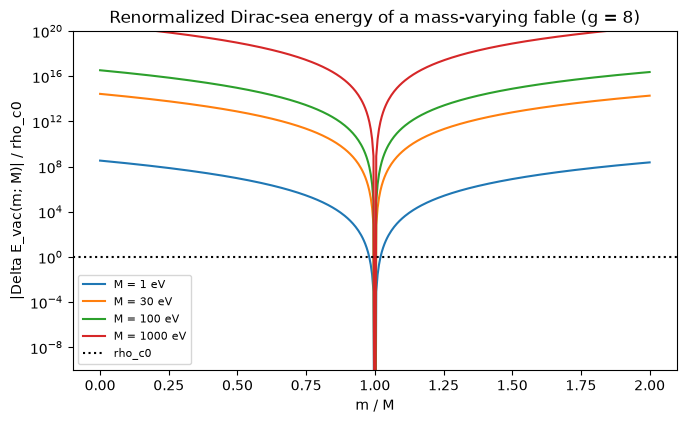

In [12]:
Ms_eV = [1.0, 30.0, 100.0, 1000.0]
mm = np.linspace(0.0, 2.0, 401)
vac_rows = []
for M_eV in Ms_eV:
    M = M_eV / E_C_EV
    for f_ in mm:
        vac_rows.append((M_eV, f_, delta_e_vac(f_ * M, M)))
vac = np.array(vac_rows)
M_star = (64 * PI2 / G_FABLE) ** 0.25 * E_C_EV
print(f'Delta E_vac(0; M) = g M^4/(64 pi^2): check {delta_e_vac(0.0, 7.0) / (G_FABLE * 7.0 ** 4 / (64 * PI2)):.15f};  '
      f'g M^4/(64 pi^2) exceeds rho_c0 for M > (64 pi^2/g)^(1/4) E_c = {M_star * 1e3:.3f} meV')
for M_eV in Ms_eV:
    M = M_eV / E_C_EV
    print(f'M = {M_eV:6g} eV: |Delta E_vac|/rho_c0 at m/M = 0.99: {abs(delta_e_vac(0.99 * M, M)):.3e};  0.9: {abs(delta_e_vac(0.9 * M, M)):.3e};  '
          f'0.5: {abs(delta_e_vac(0.5 * M, M)):.3e};  0: {abs(delta_e_vac(0.0, M)):.3e}')
r5 = delta_e_vac(1.02 * 3.0, 3.0) / delta_e_vac(1.01 * 3.0, 3.0)
print(f'fifth-order zero: Delta E_vac(M(1 + 2d))/Delta E_vac(M(1 + d)) at d = 0.01: {r5:.4f} (2^5 = 32)')
assert abs(delta_e_vac(0.0, 7.0) / (G_FABLE * 7.0 ** 4 / (64 * PI2)) - 1) < 1e-14 and abs(r5 - 32) < 1.5 and delta_e_vac(3.0, 3.0) == 0.0
with open(RESULTS / 'nb05_vacuum_energy.csv', 'w', newline='') as f:
    wr = csv.writer(f); wr.writerow(['M_eV', 'm_over_M', 'DeltaE_vac_over_rhoc0']); wr.writerows([[f'{a:g}', f'{b:.6f}', f'{c_:.10e}'] for a, b, c_ in vac_rows])

pw = run_fermion('nb05_fable4d_power0.236_m30', 'fable4d', '--potential', 'power', '--param', 'nu=0.236', '--param', 'm_today_ev=30', '--points', '1001',
                 label='fable4d power nu=0.236, m_today = 30 eV', quiet=True)
cp = pw['cols']
m_today = cp['m_eff'][-1]
vac_py = np.array([delta_e_vac(m, m_today) for m in cp['m_eff']])
vac_scale = G_FABLE * m_today ** 4 / (64 * PI2)           # the full variation, Delta E_vac(0; M)
dvac = np.max(np.abs(vac_py - cp['vac_over_rhoc'])) / vac_scale
vac_closed = np.array([delta_e_vac(m, m_today, closed=True) for m in cp['m_eff']])
near = np.abs(1 - cp['m_eff'] / m_today) < 0.2
print(f'closed form versus series where |1 - m/M| < 0.2: max |difference| / (g M^4/(64 pi^2)) = {np.max(np.abs(vac_closed[near] - vac_py[near])) / vac_scale:.1e}'
      f' (the closed form loses the digits that cancel; the series keeps them)')
rho_tot = cp['rho_r'] + cp['rho_b'] + cp['rho_f']
late = cp['a'] >= 0.3
print(f'\npower nu = 0.236, m_today = 30 eV: m_eff/m_today runs from {cp["m_eff"][0] / m_today:.4f} (a = 1e-12) to 1;  '
      f'max |solver vac_over_rhoc - formula| / (g M^4/(64 pi^2)) = {dvac:.1e}')
print(f'   |Delta E_vac(m(t)) - Delta E_vac(m_today)| / rho_total: max over a >= 0.3 = {np.max(np.abs(cp["vac_over_rhoc"][late]) / rho_tot[late]):.3e},  '
      f'at a = 0.5: {interp_log(cp["a"], np.abs(cp["vac_over_rhoc"]) / rho_tot, 0.5):.3e}')
assert dvac < 1e-12 and np.max(np.abs(cp['vac_over_rhoc'][late]) / rho_tot[late]) > 1.0
fig, ax = plt.subplots(figsize=(7.8, 4.4))
for M_eV in Ms_eV:
    sel = vac[:, 0] == M_eV
    ax.semilogy(vac[sel, 1], np.maximum(np.abs(vac[sel, 2]), 1e-30), label=f'M = {M_eV:g} eV')
ax.axhline(1.0, color='k', ls=':', label='rho_c0')
ax.set_ylim(1e-10, 1e20); ax.set_xlabel('m / M'); ax.set_ylabel('|Delta E_vac(m; M)| / rho_c0')
ax.set_title('Renormalized Dirac-sea energy of a mass-varying fable (g = 8)'); ax.legend(fontsize=8)
fig.savefig(RESULTS / 'nb05_vacuum_energy.png', dpi=130, bbox_inches='tight'); print('figure: results/nb05_vacuum_energy.png'); plt.show()

## 6. This notebook's results

Everything this notebook writes lives under `results/`:

- `results/nb05_clifford_table.csv` — the symmetry table of 3.1 and what it means for a real
  Grassmann spinor;
- `results/nb05_ks_accuracy.csv`, `results/nb05_ks_accuracy.png` — relative errors of the closed
  and stable Fermi-sea forms against quadrature, `1e−8 ≤ x ≤ 1e6`;
- `results/nb05_w_ks.csv`, `results/nb05_w_ks.png` — `w_KS(x)`;
- `results/nb05_identities.csv` — the largest residuals of the thermodynamic identities;
- `results/nb05_classical_vs_quantum.csv`, `results/nb05_classical_vs_quantum.png` — quantum versus
  classical `w` for five potentials;
- `results/nb05_gap_roots.csv`, `results/nb05_gap_roots.png` — the repulsive quadratic: roots and the
  first-order jump;
- `results/nb05_minimax.csv`, `results/nb05_minimax.png` — `E_n[σ]` and `Ω_n(m)`;
- `results/nb05_preuniverse_cooling.csv`, `results/nb05_preuniverse_cooling.png` — `w(a/a_nr)`;
- `results/nb05_vacuum_energy.csv`, `results/nb05_vacuum_energy.png` — `ΔE_vac(m; M)/ρ_c0`;
- `results/nb05_fable4d_mass30.csv`, `results/nb05_fable4d_power0.236_m30.csv` — the two solver runs.

The files are plain text: the cell below reads two of them back with Python's `csv` module alone
(no numpy, no solver) and prints them.

In [13]:
import csv
with open(RESULTS / 'nb05_identities.csv', newline='') as f:
    rows = list(csv.DictReader(f))
print(f'nb05_identities.csv: {len(rows)} rows, columns {", ".join(rows[0].keys())}')
for r in rows:
    print(f"  {r['identity']:36s} {r['largest_residual']}")
with open(RESULTS / 'nb05_fable4d_mass30.csv', newline='') as f:
    lines = [l for l in f if not l.startswith('#')]
reader = csv.DictReader(lines)
data = list(reader)
print(f'nb05_fable4d_mass30.csv: {len(data)} rows, {len(reader.fieldnames)} columns; first and last row:')
for r in (data[0], data[-1]):
    print(f"  a = {float(r['a']):.4e}   w_qp = {float(r['w_qp']):.6f}   rho_f = {float(r['rho_f']):.6e}   H_A = {float(r['H_A']):.6e}")

nb05_identities.csv: 6 rows, columns identity, largest_residual
  eps - 3P - m sigma (rel. to eps)     1.532e-15
  eps + P - wF n (rel.)                5.551e-16
  d eps/dn|m - wF (rel.)               7.439e-11
  d eps/dm|kF - sigma (rel.)           3.610e-08
  chi - d sigma/dm (rel.)              2.633e-07
  max chi/chi0                         1.000e+00
nb05_fable4d_mass30.csv: 1001 rows, 47 columns; first and last row:
  a = 1.0000e-12   w_qp = 0.333333   rho_f = 4.874365e+42   H_A = 9.847356e+21
  a = 1.0000e+00   w_qp = 0.000000   rho_f = 9.506647e-01   H_A = 1.000000e+00


## 7. What the numbers say

The cell below collects, from the cells above, the numbers behind each statement of this notebook
and prints them as a short report.  It fails if any statement is contradicted: that the stable forms
agree with quadrature and with the Rust solver; that `w_KS` runs monotonically from 1/3 to 0; that
the identities hold; that the quantum `w` never goes below −1 while the classical `expdamp` and
`lorentz` cross it; that the repulsive quadratic has three roots and a first-order jump; that the
mass-term root is a maximum of the no-sea functional; and that the Dirac-sea energy of a
mass-varying fable exceeds the critical density.

In [14]:
min_wq = min(r['w_quantum'] for r in cq_rows if r['rho_over_A'] > 0)
min_wcl = {k: float(curves[(k, 'classical')].min()) for k in ('expdamp', 'lorentz')}
assert min_wq >= -1 - 1e-12 and all(v < -1 for v in min_wcl.values())
report = f"""
**Summary, computed in this notebook.**

1. The invariant bilinear forms of Spin(4,4) on `R^16` form a space of dimension {dim_inv}, both symmetric and
   chirality-diagonal; a real Grassmann 16-spinor with `σ16` has neither a mass term nor dynamics; the complex
   16-spinor is four Dirac flavours (commutant dimension {dim_comm}).
2. Quantization: `G = −iσ16γ⁴` has signature (8, 8); in the `J`-eigenbasis every one of the 8 positive-frequency modes
   per momentum has energy `+ω` and scalar density `m/ω`: `g = 8`.
3. Stable Fermi-sea forms: largest relative error against quadrature {worst_stable:.1e} over `1e−8 ≤ x ≤ 1e6`; against the
   Rust solver {worst_rust:.1e}.
4. `w_KS` rises monotonically from {wks[0]:.2e} (x = 1e−8) to {wks[-1]:.12f} (x = 1e6).
5. Identities: `ε − 3P = mσ` to {ident['eps - 3P - m sigma (rel. to eps)']:.1e}, `ε + P = wF n` to {ident['eps + P - wF n (rel.)']:.1e}.
6. Quantum versus classical: the smallest quantum `w` over all potentials, densities and scales is {min_wq:+.6f}; the classical
   `expdamp` reaches {min_wcl['expdamp']:+.4f} and `lorentz` {min_wcl['lorentz']:+.4f}.  The phantom crossing does not survive quantization.
7. Repulsive quadratic `(0.05, 20)`: {len(roots)} roots at `kF = 1` (Rust and Python agree), ground state `m = {gs['m']:+.6e}`; the ground state
   jumps from `m = {scan[jump - 1, 3]:+.4f}` to `m = {scan[jump, 3]:+.4f}` near `kF = {scan[jump, 0]:.3f}`: a first-order transition.
8. The mass-term root is a maximum of `E_n[σ]` (value {E_star:.6f} = ρ); `E_n/n → {E_curve[0] / n_m:+.4f}` as `σ → −n` (collapse to −|m0| = −2).
   The Walecka functional of `W = σ − 10σ²` is convex with its minimum {Om(ra[0]):.6f} = ρ at `m* = {ra[0]:.6f}`.
9. On the pre-universe the author's mass term gives `w` from 1/3 to 0 as `a = e^(−a4)` grows through `a_nr`; the Rust run agrees to {dw:.1e}.
10. Dirac-sea energy: its full variation `g M⁴/(64π²)` exceeds `ρ_c0` for `M > {M_star * 1e3:.2f} meV`; along the power run (30 eV) it
    reaches {np.max(np.abs(cp['vac_over_rhoc'][late]) / rho_tot[late]):.2e} times the total density at `a ≥ 0.3`.
"""
display(Markdown(report))
print('every statement of this notebook is backed by the numbers above')


**Summary, computed in this notebook.**

1. The invariant bilinear forms of Spin(4,4) on `R^16` form a space of dimension 2, both symmetric and
   chirality-diagonal; a real Grassmann 16-spinor with `σ16` has neither a mass term nor dynamics; the complex
   16-spinor is four Dirac flavours (commutant dimension 16).
2. Quantization: `G = −iσ16γ⁴` has signature (8, 8); in the `J`-eigenbasis every one of the 8 positive-frequency modes
   per momentum has energy `+ω` and scalar density `m/ω`: `g = 8`.
3. Stable Fermi-sea forms: largest relative error against quadrature 9.9e-14 over `1e−8 ≤ x ≤ 1e6`; against the
   Rust solver 3.1e-14.
4. `w_KS` rises monotonically from 2.00e-17 (x = 1e−8) to 0.333333333333 (x = 1e6).
5. Identities: `ε − 3P = mσ` to 1.5e-15, `ε + P = wF n` to 5.6e-16.
6. Quantum versus classical: the smallest quantum `w` over all potentials, densities and scales is -0.999572; the classical
   `expdamp` reaches -1.3020 and `lorentz` -1.2481.  The phantom crossing does not survive quantization.
7. Repulsive quadratic `(0.05, 20)`: 3 roots at `kF = 1` (Rust and Python agree), ground state `m = -1.640337e-02`; the ground state
   jumps from `m = +0.4756` to `m = -0.0998` near `kF = 0.625`: a first-order transition.
8. The mass-term root is a maximum of `E_n[σ]` (value 1.052962 = ρ); `E_n/n → -1.9995` as `σ → −n` (collapse to −|m0| = −2).
   The Walecka functional of `W = σ − 10σ²` is convex with its minimum 0.121193 = ρ at `m* = 0.211249`.
9. On the pre-universe the author's mass term gives `w` from 1/3 to 0 as `a = e^(−a4)` grows through `a_nr`; the Rust run agrees to 1.1e-15.
10. Dirac-sea energy: its full variation `g M⁴/(64π²)` exceeds `ρ_c0` for `M > 7.34 meV`; along the power run (30 eV) it
    reaches 1.31e+13 times the total density at `a ≥ 0.3`.


every statement of this notebook is backed by the numbers above


## 8. Name this notebook and save it

The last two cells are the interactive ones.  The first asks you for a name for this notebook
(press Enter to keep the current one); the second opens the usual graphical *Save as* dialog so
you can put a copy of the notebook -- with all the outputs you have just produced -- wherever you
like.  When the notebook is executed headlessly (by `run_all.sh`, `run_all.ps1` or `nbconvert`)
there is nobody to answer, so both cells detect that and print a one-line notice instead.

In [15]:
import os, sys

def headless_now():
    """True when nobody can answer a prompt: nbconvert / nbclient execution (the kernel's stdin is
    disabled), a FABLE_HEADLESS environment variable, or a plain Python run without a terminal."""
    if os.environ.get('FABLE_HEADLESS'):
        return True
    try:
        return not get_ipython().kernel._allow_stdin
    except Exception:
        return not sys.stdin.isatty()

HEADLESS = headless_now()
if HEADLESS:
    NOTEBOOK_NAME = '05_fermion_fable_quantum_eos'
    print('Headless execution: no prompt; the notebook keeps its name', NOTEBOOK_NAME)
else:
    NOTEBOOK_NAME = input('Name for this notebook: ').strip() or '05_fermion_fable_quantum_eos'
    print('This notebook is called', NOTEBOOK_NAME)

Headless execution: no prompt; the notebook keeps its name 05_fermion_fable_quantum_eos


If the graphical dialog cannot be opened (no display, or Tk missing from your Python), the cell
falls back to asking for a folder path in plain text and copies the notebook there.

In [16]:
import shutil
from pathlib import Path

if globals().get('HEADLESS', True):
    print('Headless execution: the save dialog is skipped; the notebook stays where it is.')
else:
    target = ''
    try:
        import tkinter
        from tkinter import filedialog
        root = tkinter.Tk()
        root.withdraw()
        root.attributes('-topmost', True)
        target = filedialog.asksaveasfilename(title='Save a copy of this notebook as',
                                              initialfile=NOTEBOOK_NAME + '.ipynb', defaultextension='.ipynb',
                                              filetypes=[('Jupyter notebook', '*.ipynb'), ('All files', '*.*')])
        root.destroy()
    except Exception as exc:
        print(f'No graphical dialog is available ({exc}). Falling back to a typed folder path.')
        folder = input('Folder to save a copy of this notebook into (empty = do not save): ').strip()
        if folder:
            target = str(Path(folder) / (NOTEBOOK_NAME + '.ipynb'))
    if target:
        shutil.copyfile(Path.cwd() / '05_fermion_fable_quantum_eos.ipynb', target)
        print('A copy of this notebook was saved as', target)
    else:
        print('Nothing saved.')

Headless execution: the save dialog is skipped; the notebook stays where it is.
